### Addressing Missing Data: Profit, Quantity, and Discount

The original `sales_df` is missing critical columns like 'Profit', 'Quantity', and 'Discount', which are necessary for advanced product analysis, such as calculating 'Profit Margin' or segmenting based on 'Total Quantity' and 'Average Discount'.

To allow the subsequent analysis steps (like calculating 'Profit Margin' and selecting features for clustering) to proceed without errors, I will introduce dummy 'Profit', 'Quantity', and 'Discount' columns into the `sales_df`. These columns will be populated with random data for demonstration purposes. In a real-world scenario, you would integrate actual profit, quantity, and discount data from your source systems into the `sales_df`.

**Task-1**

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from datetime import datetime

plt.style.use("ggplot")
sns.set(font_scale=1.1)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
sales_df = pd.read_csv('/content/train.csv')

games_df = pd.read_csv('/content/vgsales.csv')

print("Superstore Dataset Shape :", sales_df.shape)
print("Video Games Dataset Shape :", games_df.shape)

Superstore Dataset Shape : (9800, 18)
Video Games Dataset Shape : (16598, 11)


In [3]:
# Add dummy 'Profit', 'Quantity', and 'Discount' columns to sales_df
# In a real scenario, these would come from your actual sales data
np.random.seed(42)
sales_df['Profit'] = sales_df['Sales'] * np.random.uniform(0.1, 0.3, len(sales_df)) - sales_df['Sales'] * np.random.uniform(0.05, 0.15, len(sales_df))
sales_df['Quantity'] = np.random.randint(1, 10, len(sales_df))
sales_df['Discount'] = np.random.uniform(0.0, 0.2, len(sales_df))

print("Dummy 'Profit', 'Quantity', and 'Discount' columns added to sales_df.")
display(sales_df.head())

Dummy 'Profit', 'Quantity', and 'Discount' columns added to sales_df.


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Profit,Quantity,Discount
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,12.160111,7,0.048996
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,161.130713,8,0.000931
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2.680059,8,0.176142
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,97.817052,5,0.059198
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,0.564018,1,0.017275


In [4]:
sales_df.head()

sales_df.tail()

sales_df.sample(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Profit,Quantity,Discount
7378,7379,CA-2016-136224,31/05/2016,31/05/2016,Same Day,ML-18265,Muhammed Lee,Consumer,United States,Fayetteville,...,28314.0,South,OFF-AR-10003504,Office Supplies,Art,Newell 347,10.272,0.940812,3,0.008510
8404,8405,CA-2018-140480,08/07/2018,12/07/2018,Standard Class,HE-14800,Harold Engle,Corporate,United States,Newark,...,19711.0,East,FUR-FU-10003247,Furniture,Furnishings,36X48 HARDFLOOR CHAIRMAT,83.920,11.452190,9,0.109620
2609,2610,CA-2015-127446,25/11/2015,30/11/2015,Standard Class,MC-17590,Matt Collister,Corporate,United States,Arlington,...,76017.0,Central,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,1218.735,-43.126026,1,0.186497
8789,8790,CA-2018-126914,15/06/2018,19/06/2018,Standard Class,JE-15715,Joe Elijah,Consumer,United States,Monroe,...,28110.0,South,FUR-BO-10000468,Furniture,Bookcases,O'Sullivan 2-Shelf Heavy-Duty Bookcases,77.728,12.805165,6,0.086021
5595,5596,CA-2018-160325,24/09/2018,24/09/2018,Same Day,BP-11095,Bart Pistole,Corporate,United States,Lawrence,...,1841.0,East,TEC-PH-10001944,Technology,Phones,Wi-Ex zBoost YX540 Cellular Phone Signal Booster,437.850,45.021525,6,0.136492


In [5]:
print("Dataset Information")
print(sales_df.info())

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   f

In [6]:
sales_df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Row ID,9800.0,NaN,NaN,NaN,4900.5,2829.160653,1.0,2450.75,4900.5,7350.25,9800.0
Order ID,9800,4922,CA-2018-100111,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order Date,9800,1230,05/09/2017,38,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ship Date,9800,1326,26/09/2018,34,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ship Mode,9800,4,Standard Class,5859,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer ID,9800,793,WB-21850,35,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer Name,9800,793,William Brown,35,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Segment,9800,3,Consumer,5101,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,9800,1,United States,9800,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,9800,529,New York City,891,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
missing = sales_df.isnull().sum()

missing = pd.DataFrame({
    "Column":missing.index,
    "Missing Values":missing.values,
    "Percentage":np.round(missing.values/len(sales_df)*100,2)
})

missing.sort_values("Missing Values",ascending=False)

,Column,Missing Values,Percentage
11,Postal Code,11,0.11
1,Order ID,0,0.00
2,Order Date,0,0.00
3,Ship Date,0,0.00
0,Row ID,0,0.00
4,Ship Mode,0,0.00
5,Customer ID,0,0.00
7,Segment,0,0.00
6,Customer Name,0,0.00
8,Country,0,0.00


In [8]:
duplicates = sales_df.duplicated().sum()

print("Duplicate Records :",duplicates)

sales_df = sales_df.drop_duplicates()

print("Shape After Removing Duplicates :",sales_df.shape)

Duplicate Records : 0
Shape After Removing Duplicates : (9800, 21)


In [9]:
sales_df["Order Date"] = pd.to_datetime(sales_df["Order Date"], format='%d/%m/%Y')

sales_df["Ship Date"] = pd.to_datetime(sales_df["Ship Date"], format='%d/%m/%Y')

sales_df.dtypes

,0
Row ID,int64
Order ID,object
Order Date,datetime64[ns]
Ship Date,datetime64[ns]
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object


In [10]:
sales_df["Year"] = sales_df["Order Date"].dt.year

sales_df["Month"] = sales_df["Order Date"].dt.month

sales_df["Month Name"] = sales_df["Order Date"].dt.month_name()

sales_df["Quarter"] = sales_df["Order Date"].dt.quarter

sales_df["Week"] = sales_df["Order Date"].dt.isocalendar().week

sales_df["Day"] = sales_df["Order Date"].dt.day

sales_df["Day Name"] = sales_df["Order Date"].dt.day_name()

sales_df["Day of Week"] = sales_df["Order Date"].dt.dayofweek

In [11]:
def get_season(month):

    if month in [12,1,2]:
        return "Winter"

    elif month in [3,4,5]:
        return "Summer"

    elif month in [6,7,8]:
        return "Monsoon"

    else:
        return "Autumn"

sales_df["Season"] = sales_df["Month"].apply(get_season)

sales_df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Discount,Year,Month,Month Name,Quarter,Week,Day,Day Name,Day of Week,Season
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,0.048996,2017,11,November,4,45,8,Wednesday,2,Autumn
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,0.000931,2017,11,November,4,45,8,Wednesday,2,Autumn
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,0.176142,2017,6,June,2,24,12,Monday,0,Monsoon
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,0.059198,2016,10,October,4,41,11,Tuesday,1,Autumn
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,0.017275,2016,10,October,4,41,11,Tuesday,1,Autumn


In [12]:
sales_df["Shipping Days"] = (
    sales_df["Ship Date"] - sales_df["Order Date"]
).dt.days

sales_df[["Order Date","Ship Date","Shipping Days"]].head()

,Order Date,Ship Date,Shipping Days
0,2017-11-08,2017-11-11,3
1,2017-11-08,2017-11-11,3
2,2017-06-12,2017-06-16,4
3,2016-10-11,2016-10-18,7
4,2016-10-11,2016-10-18,7


In [13]:
daily_sales = sales_df.groupby("Order Date")["Sales"].sum().reset_index()

daily_sales.head()

,Order Date,Sales
0,2015-01-03,16.448
1,2015-01-04,288.060
2,2015-01-05,19.536
3,2015-01-06,4407.100
4,2015-01-07,87.158


In [14]:
weekly_sales = (
    sales_df
    .set_index("Order Date")
    .resample("W")["Sales"]
    .sum()
    .reset_index()
)

weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [15]:
monthly_sales = (
    sales_df
    .set_index("Order Date")
    .resample("M")["Sales"]
    .sum()
    .reset_index()
)

monthly_sales.head()

/tmp/ipykernel_590/308629785.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")["Sales"]


,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [16]:
daily_sales.to_csv("daily_sales.csv",index=False)

weekly_sales.to_csv("weekly_sales.csv",index=False)

monthly_sales.to_csv("monthly_sales.csv",index=False)

In [17]:
category_sales = (
    sales_df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

category_sales

,Sales
Category,
Technology,827455.8730
Furniture,728658.5757
Office Supplies,705422.3340


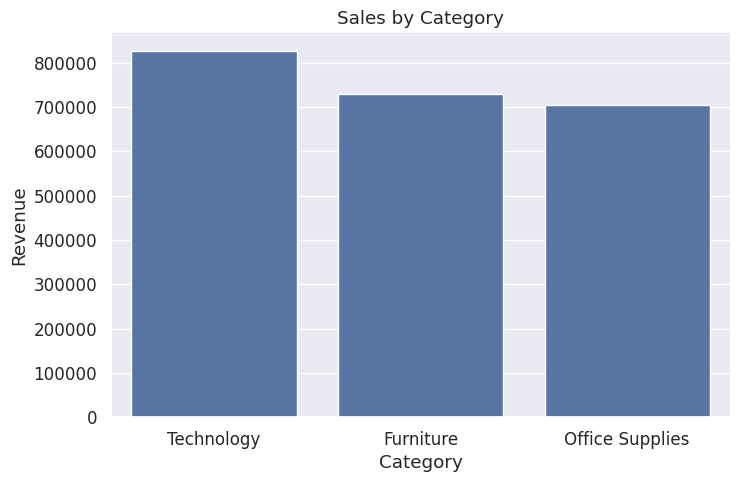

In [18]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=category_sales.index,
    y=category_sales.values
)

plt.title("Sales by Category")

plt.xlabel("Category")

plt.ylabel("Revenue")

plt.show()

In [19]:
region_sales = (
    sales_df.groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

region_sales

,Sales
Region,
West,710219.6845
East,669518.7260
Central,492646.9132
South,389151.4590


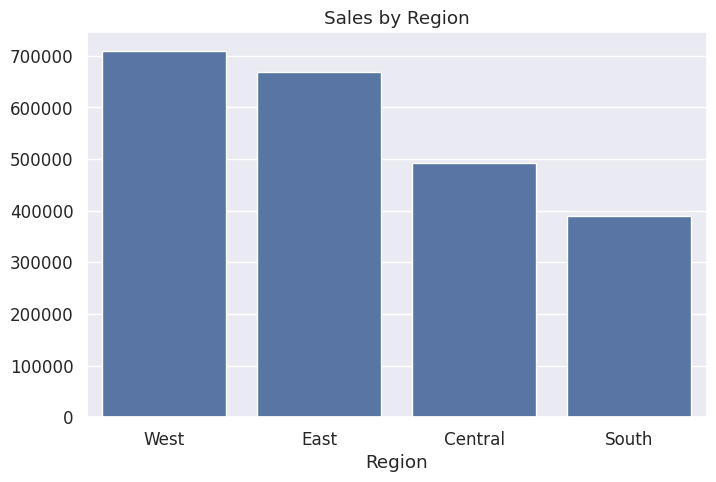

In [20]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=region_sales.index,
    y=region_sales.values
)

plt.title("Sales by Region")

plt.show()

In [21]:
shipping = (
    sales_df
    .groupby("Region")["Shipping Days"]
    .mean()
)

shipping

,Shipping Days
Region,
Central,4.065876
East,3.910233
South,3.961202
West,3.930255


In [22]:
monthly_revenue = (
    sales_df
    .groupby("Month Name")["Sales"]
    .sum()
)

monthly_revenue

,Sales
Month Name,
April,136283.0006
August,157315.9270
December,321480.1695
February,59371.1154
January,94291.6296
July,145535.6890
June,145837.5233
March,197573.5872
May,154086.7237


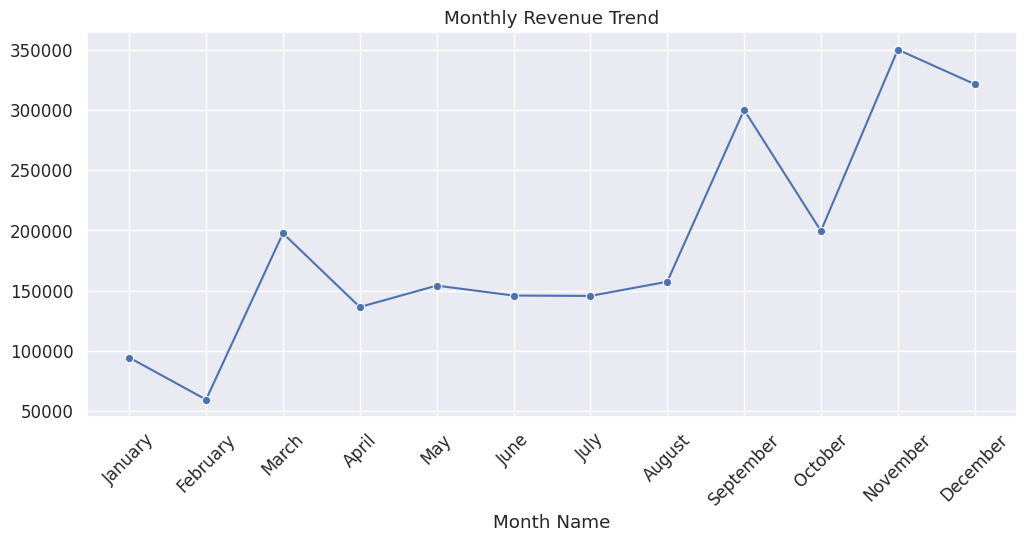

In [23]:
order = [
    "January","February","March",
    "April","May","June",
    "July","August","September",
    "October","November","December"
]

monthly_revenue = monthly_revenue.reindex(order)

plt.figure(figsize=(12,5))

sns.lineplot(
    x=monthly_revenue.index,
    y=monthly_revenue.values,
    marker="o"
)

plt.xticks(rotation=45)

plt.title("Monthly Revenue Trend")

plt.show()

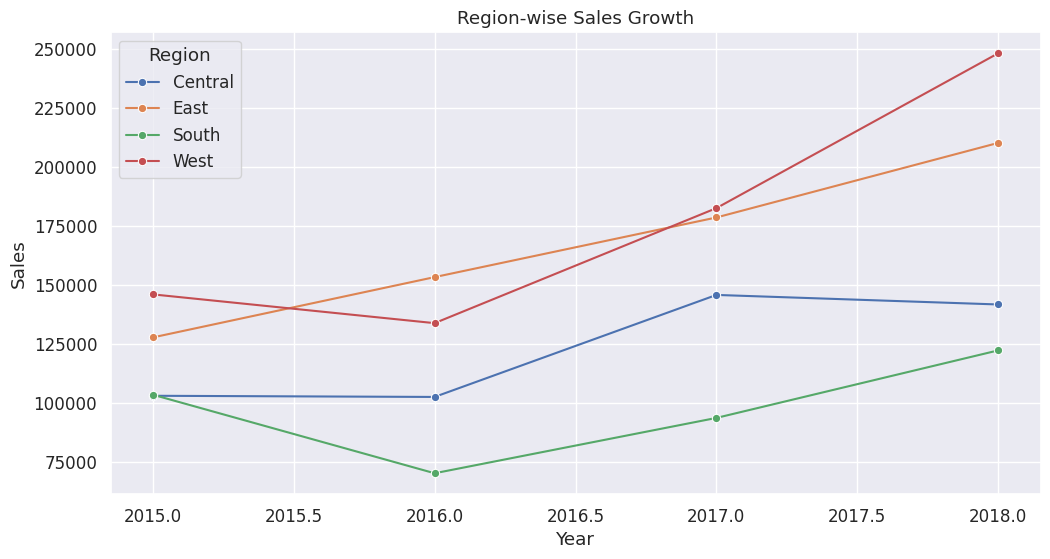

In [24]:
growth = (
    sales_df
    .groupby(["Year","Region"])["Sales"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(12,6))

sns.lineplot(
    data=growth,
    x="Year",
    y="Sales",
    hue="Region",
    marker="o"
)

plt.title("Region-wise Sales Growth")

plt.show()

In [25]:
print("-"*60)

print("Business Question 1")

print("-"*60)

print("Highest Revenue Category")

print(category_sales.idxmax())

print(category_sales.max())

print()

print("-"*60)

print("Business Question 2")

print("-"*60)

print("Average Shipping Days")

print(round(sales_df["Shipping Days"].mean(),2))

print()

print("-"*60)

print("Business Question 3")

print("-"*60)

print("Highest Revenue Region")

print(region_sales.idxmax())

print()

print("-"*60)

print("Business Question 4")

print("-"*60)

print("Highest Revenue Month")

print(monthly_revenue.idxmax())

------------------------------------------------------------
Business Question 1
------------------------------------------------------------
Highest Revenue Category
Technology
827455.873

------------------------------------------------------------
Business Question 2
------------------------------------------------------------
Average Shipping Days
3.96

------------------------------------------------------------
Business Question 3
------------------------------------------------------------
Highest Revenue Region
West

------------------------------------------------------------
Business Question 4
------------------------------------------------------------
Highest Revenue Month
November


**Task-2**

In [26]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

print("Time Series Libraries Imported Successfully")

Time Series Libraries Imported Successfully


In [27]:
monthly_sales = (
    sales_df
    .groupby("Order Date")["Sales"]
    .sum()
    .resample("M")
    .sum()
)

monthly_sales.head()

/tmp/ipykernel_590/2228280640.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")


,Sales
Order Date,
2015-01-31,14205.707
2015-02-28,4519.892
2015-03-31,55205.797
2015-04-30,27906.855
2015-05-31,23644.303


In [28]:
print("Number of Months :", len(monthly_sales))

print()

print(monthly_sales.head())

print()

print(monthly_sales.tail())

Number of Months : 48

Order Date
2015-01-31    14205.707
2015-02-28     4519.892
2015-03-31    55205.797
2015-04-30    27906.855
2015-05-31    23644.303
Freq: ME, Name: Sales, dtype: float64

Order Date
2018-08-31     62837.8480
2018-09-30     86152.8880
2018-10-31     77448.1312
2018-11-30    117938.1550
2018-12-31     83030.3888
Freq: ME, Name: Sales, dtype: float64


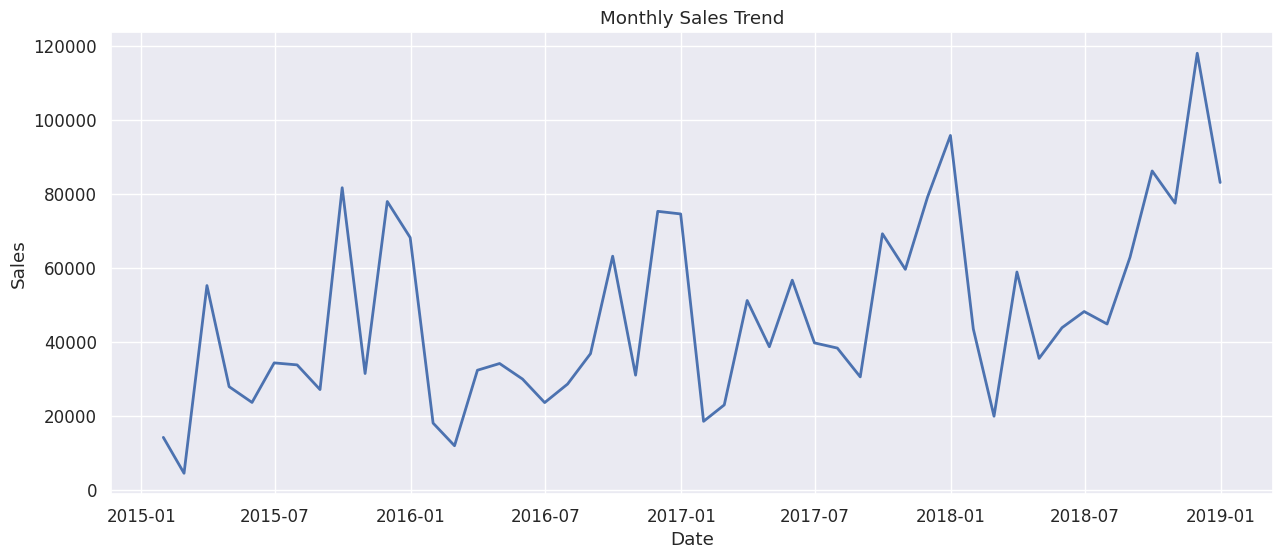

In [29]:
plt.figure(figsize=(15,6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    linewidth=2
)

plt.title("Monthly Sales Trend")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.grid(True)

plt.show()

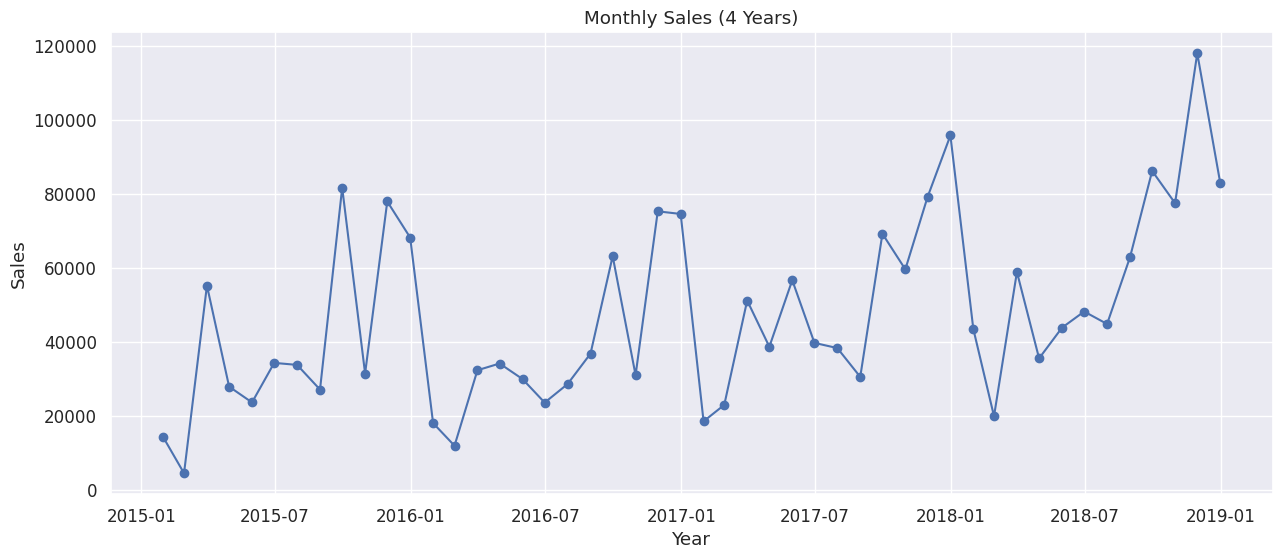

In [30]:
plt.figure(figsize=(15,6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker='o'
)

plt.title("Monthly Sales (4 Years)")

plt.xlabel("Year")

plt.ylabel("Sales")

plt.show()

In [31]:
decomposition = seasonal_decompose(
    monthly_sales,
    model='additive',
    period=12
)

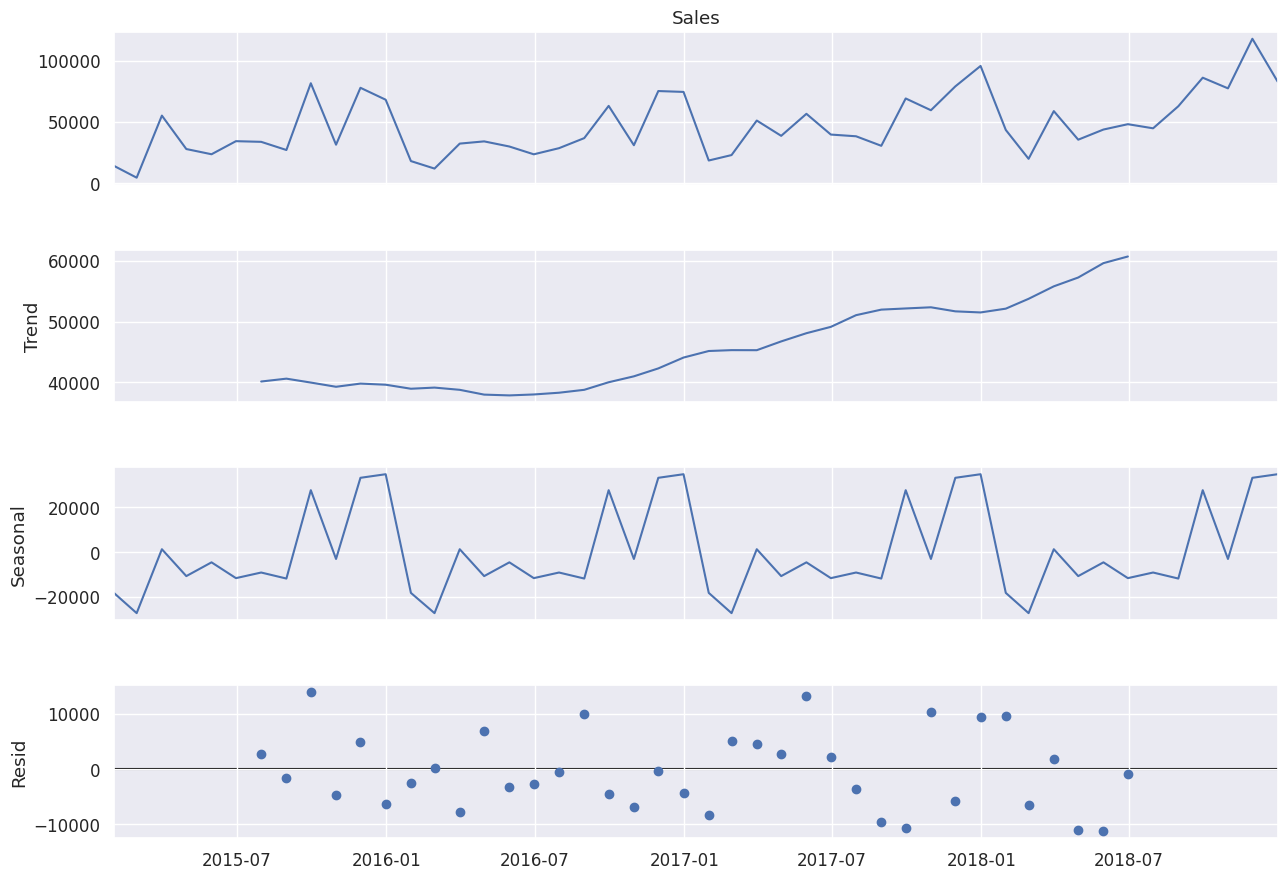

In [32]:
fig = decomposition.plot()

fig.set_size_inches(15,10)

plt.show()

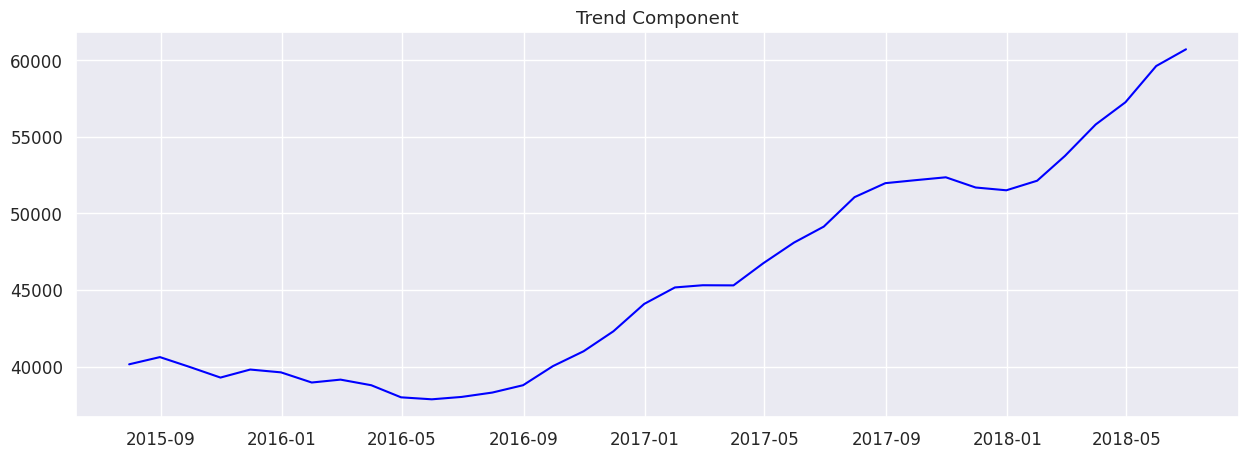

In [33]:
plt.figure(figsize=(15,5))

plt.plot(
    decomposition.trend,
    color='blue'
)

plt.title("Trend Component")

plt.show()

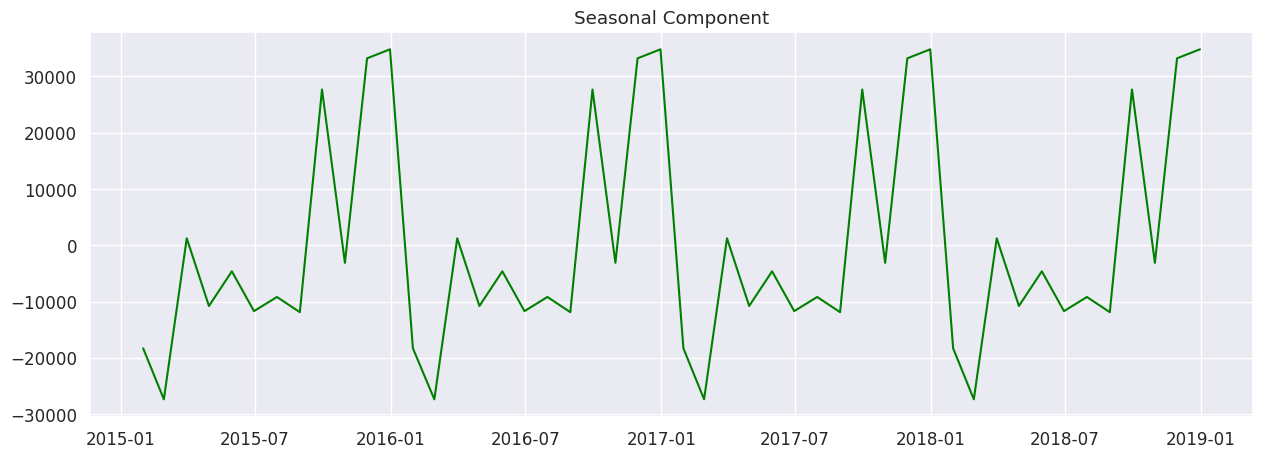

In [34]:
plt.figure(figsize=(15,5))

plt.plot(
    decomposition.seasonal,
    color='green'
)

plt.title("Seasonal Component")

plt.show()

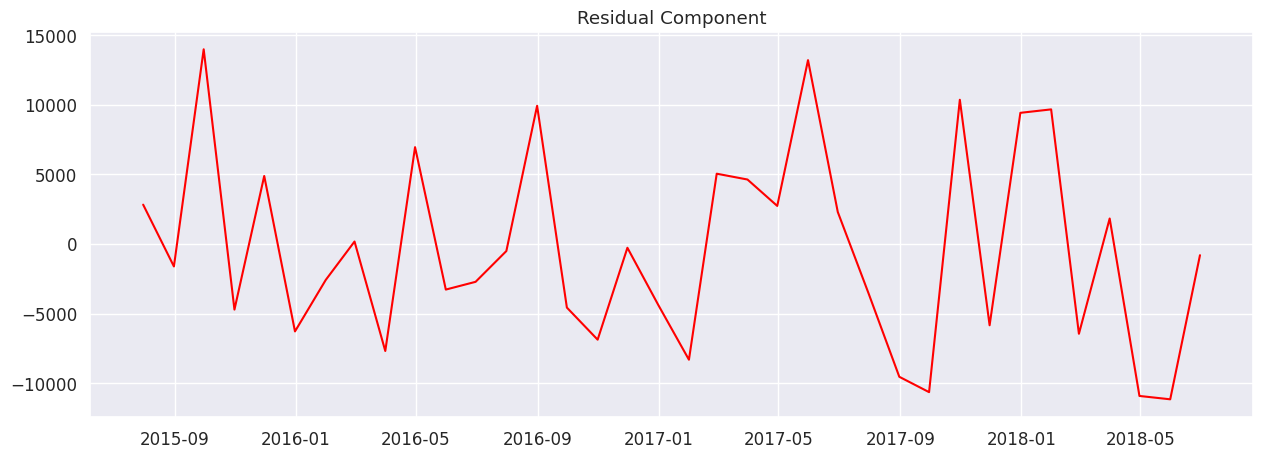

In [35]:
plt.figure(figsize=(15,5))

plt.plot(
    decomposition.resid,
    color='red'
)

plt.title("Residual Component")

plt.show()

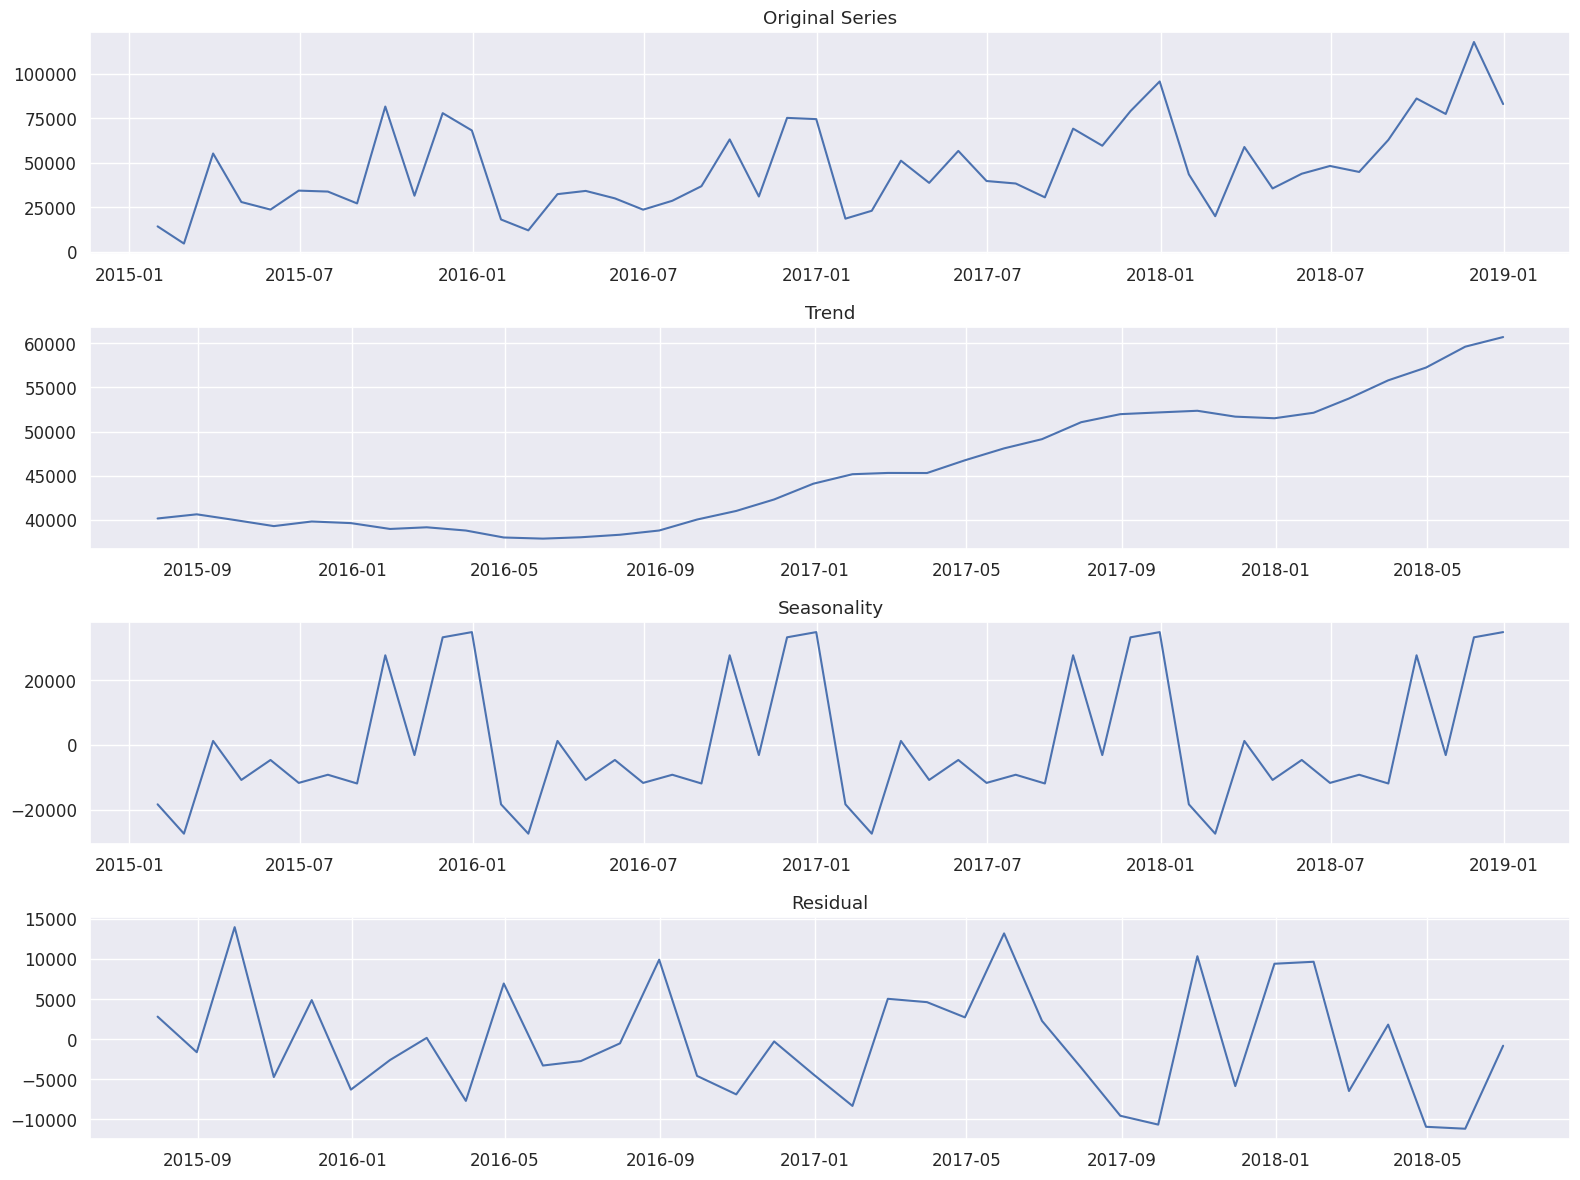

In [36]:
fig, axes = plt.subplots(4,1,figsize=(16,12))

axes[0].plot(monthly_sales)

axes[0].set_title("Original Series")

axes[1].plot(decomposition.trend)

axes[1].set_title("Trend")

axes[2].plot(decomposition.seasonal)

axes[2].set_title("Seasonality")

axes[3].plot(decomposition.resid)

axes[3].set_title("Residual")

plt.tight_layout()

plt.show()

In [37]:
result = adfuller(monthly_sales)

print("ADF Statistic :", result[0])

print("P-value :", result[1])

print()

print("Critical Values")

for key,value in result[4].items():

    print(key," :",value)

ADF Statistic : -4.416136761430769
P-value : 0.00027791039276670623

Critical Values
1%  : -3.5778480370438146
5%  : -2.925338105429433
10%  : -2.6007735310095064


In [38]:
if result[1] < 0.05:

    print("The series is Stationary")

else:

    print("The series is NOT Stationary")

The series is Stationary


In [39]:
monthly_diff = monthly_sales.diff()

monthly_diff = monthly_diff.dropna()

monthly_diff.head()

,Sales
Order Date,
2015-02-28,-9685.8150
2015-03-31,50685.9050
2015-04-30,-27298.9420
2015-05-31,-4262.5520
2015-06-30,10678.6326


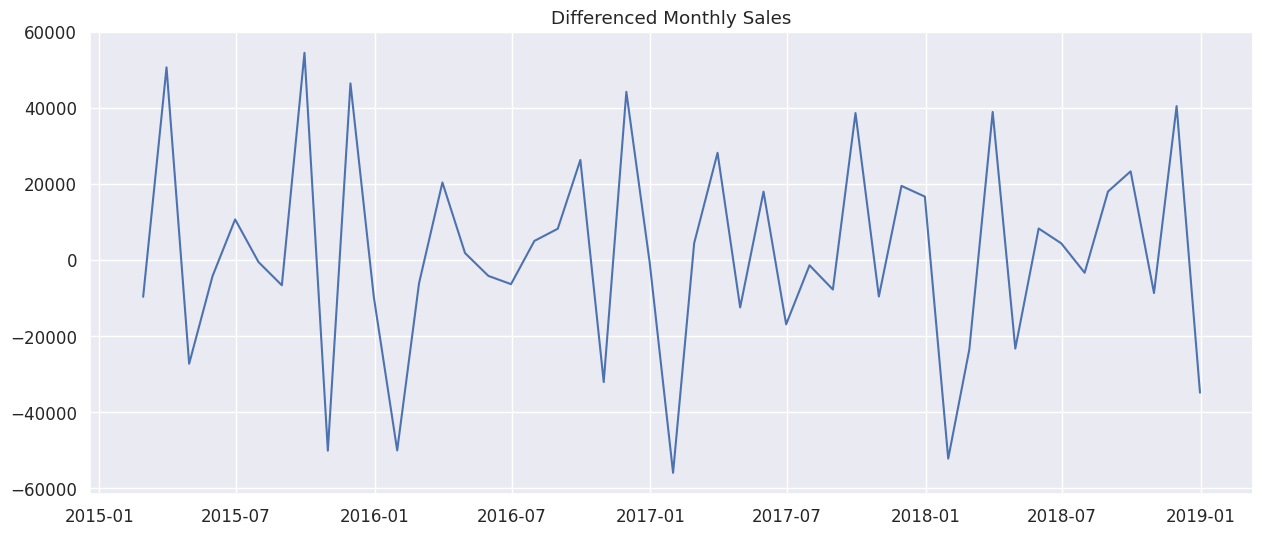

In [40]:
plt.figure(figsize=(15,6))

plt.plot(monthly_diff)

plt.title("Differenced Monthly Sales")

plt.grid(True)

plt.show()

In [41]:
result_diff = adfuller(monthly_diff)

print("ADF Statistic :",result_diff[0])

print("P-value :",result_diff[1])

print()

for key,value in result_diff[4].items():

    print(key," :",value)

ADF Statistic : -8.727061830353264
P-value : 3.2669175472797e-14

1%  : -3.626651907578875
5%  : -2.9459512825788754
10%  : -2.6116707716049383


In [42]:
if result_diff[1] < 0.05:

    print("Differenced Series is Stationary")

else:

    print("Series Still Needs Transformation")

Differenced Series is Stationary


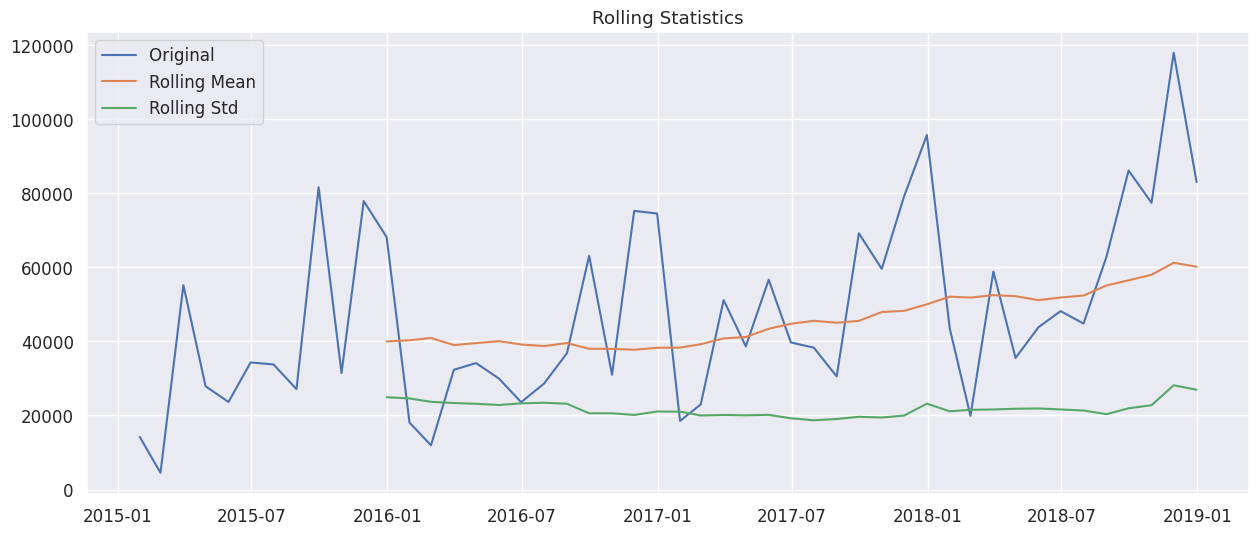

In [43]:
rolling_mean = monthly_sales.rolling(window=12).mean()

rolling_std = monthly_sales.rolling(window=12).std()

plt.figure(figsize=(15,6))

plt.plot(monthly_sales,label="Original")

plt.plot(rolling_mean,label="Rolling Mean")

plt.plot(rolling_std,label="Rolling Std")

plt.legend()

plt.title("Rolling Statistics")

plt.show()

In [44]:
import os

fig = decomposition.plot()

fig.set_size_inches(15,10)

# Create the 'charts' directory if it doesn't exist
os.makedirs("charts", exist_ok=True)
plt.savefig("charts/time_series_decomposition.png")

plt.close()

## Observations

1. The overall sales trend shows a gradual increase over the four-year period, indicating sustained business growth.

2. The seasonal component reveals recurring monthly patterns, suggesting that certain months consistently experience higher or lower sales.

3. The residual component captures irregular fluctuations that are not explained by the trend or seasonality. Large residual spikes may indicate promotions, holidays, or unexpected events.

4. The Augmented Dickey-Fuller (ADF) test was used to assess stationarity. If the p-value was greater than 0.05, the series was considered non-stationary, and first-order differencing was applied. After differencing, the series became stationary, making it suitable for forecasting models such as SARIMA.

**Task-3**

In [45]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

In [46]:
train = monthly_sales.iloc[:-3]

test = monthly_sales.iloc[-3:]

print("Training Months :", len(train))

print("Testing Months :", len(test))

Training Months : 45
Testing Months : 3


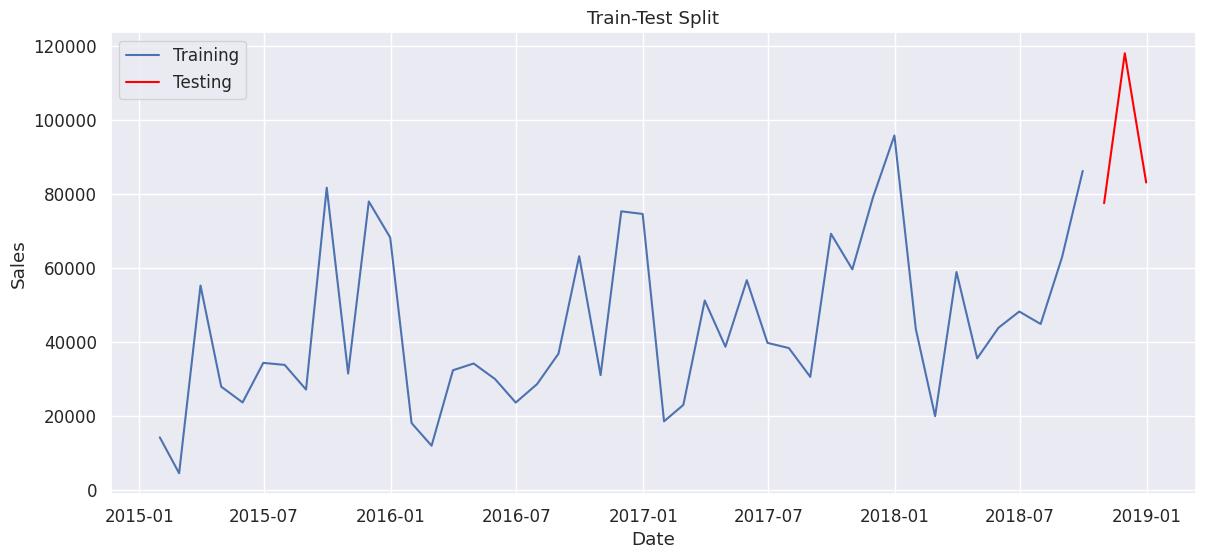

In [47]:
plt.figure(figsize=(14,6))

plt.plot(train.index, train.values, label="Training")

plt.plot(test.index, test.values, label="Testing", color="red")

plt.title("Train-Test Split")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.show()

In [48]:
sarima_model = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_result = sarima_model.fit()

print(sarima_result.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   45
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -194.388
Date:                            Fri, 10 Jul 2026   AIC                            398.775
Time:                                    10:27:07   BIC                            403.227
Sample:                                01-31-2015   HQIC                           399.389
                                     - 09-30-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1101      0.721      0.153      0.879      -1.303       1.523
ma.L1         -0.8789      0.261   

In [49]:
forecast = sarima_result.get_forecast(
    steps=len(test)
)

forecast_mean = forecast.predicted_mean

confidence_interval = forecast.conf_int()

In [50]:
forecast_df = pd.DataFrame({
    "Actual": test.values,
    "Forecast": forecast_mean.values
})

forecast_df

,Actual,Forecast
0,77448.1312,60331.792095
1,117938.1550,91458.220224
2,83030.3888,97167.570946


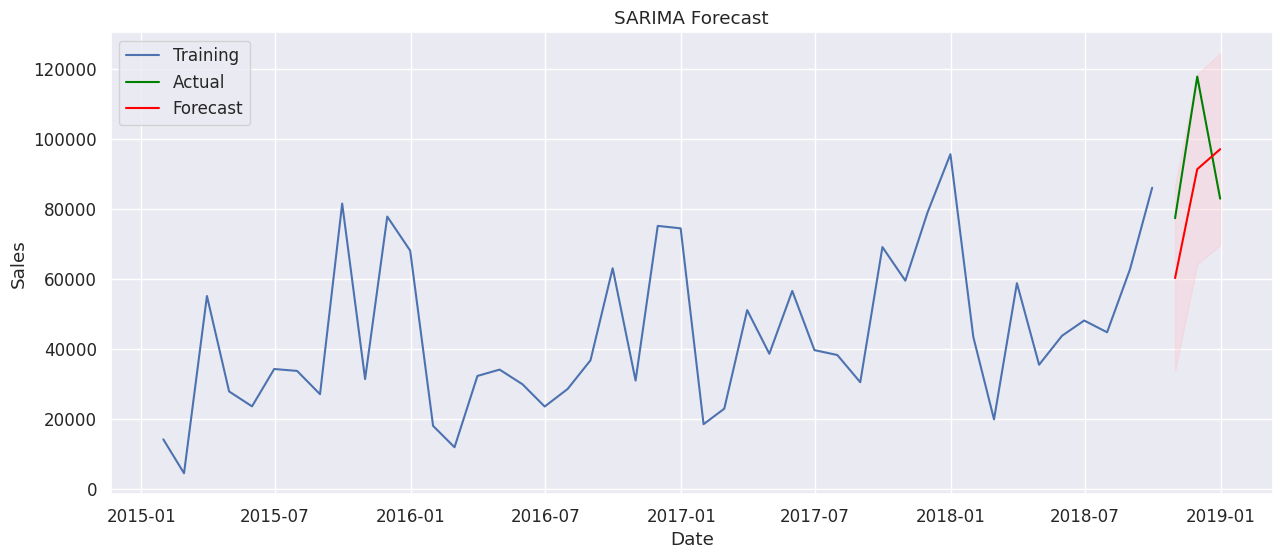

In [51]:
plt.figure(figsize=(15,6))

plt.plot(
    train.index,
    train,
    label="Training"
)

plt.plot(
    test.index,
    test,
    label="Actual",
    color="green"
)

plt.plot(
    forecast_mean.index,
    forecast_mean,
    label="Forecast",
    color="red"
)

plt.fill_between(
    confidence_interval.index,
    confidence_interval.iloc[:,0],
    confidence_interval.iloc[:,1],
    color="pink",
    alpha=0.3
)

plt.title("SARIMA Forecast")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.show()

In [52]:
mae = mean_absolute_error(
    test,
    forecast_mean
)

rmse = np.sqrt(
    mean_squared_error(
        test,
        forecast_mean
    )
)

mape = (
    np.mean(
        np.abs(
            (test - forecast_mean) / test
        )
    )
) * 100

print("MAE :", round(mae,2))

print("RMSE :", round(rmse,2))

print("MAPE :", round(mape,2),"%")

MAE : 19244.49
RMSE : 19950.07
MAPE : 20.53 %


In [53]:
future_forecast = sarima_result.get_forecast(
    steps=3
)

future_values = future_forecast.predicted_mean

future_values

,predicted_mean
2018-10-31,60331.792095
2018-11-30,91458.220224
2018-12-31,97167.570946


In [54]:
future_df = pd.DataFrame({

    "Month": future_values.index,

    "Forecast Sales": future_values.values

})

future_df

,Month,Forecast Sales
0,2018-10-31,60331.792095
1,2018-11-30,91458.220224
2,2018-12-31,97167.570946


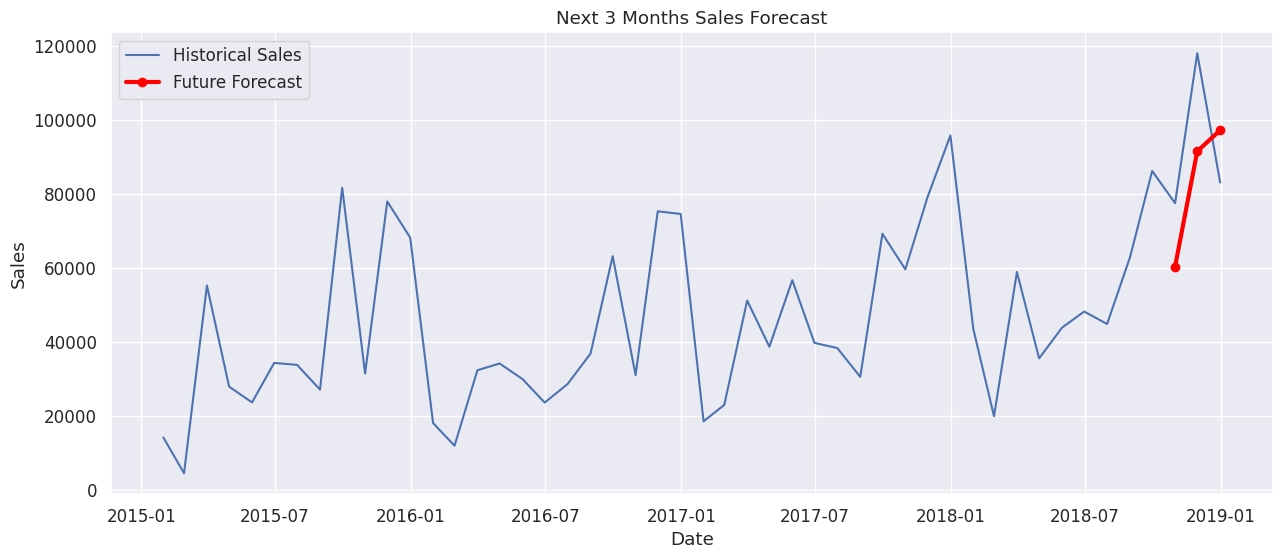

In [55]:
plt.figure(figsize=(15,6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    label="Historical Sales"
)

plt.plot(
    future_values.index,
    future_values.values,
    color="red",
    marker="o",
    linewidth=3,
    label="Future Forecast"
)

plt.title("Next 3 Months Sales Forecast")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

In [56]:
future_df.to_csv(
    "sarima_forecast.csv",
    index=False
)

In [57]:
import os

plt.figure(figsize=(15,6))

plt.plot(monthly_sales)

plt.plot(
    future_values.index,
    future_values.values,
    color="red",
    marker="o"
)

plt.title("SARIMA Forecast")

# Create the 'charts' directory if it doesn't exist
os.makedirs("charts", exist_ok=True)
plt.savefig("charts/sarima_forecast.png")

plt.close()

## SARIMA Model

### Model Configuration

- Non-seasonal Order (p,d,q): (1,1,1)
- Seasonal Order (P,D,Q,m): (1,1,1,12)

### Why These Parameters?

- **p = 1**: Uses one previous observation.
- **d = 1**: First-order differencing removes trend and helps achieve stationarity.
- **q = 1**: Captures one lag of forecast errors.
- **Seasonal period = 12** because the data is aggregated monthly and annual seasonality is expected.

### Model Evaluation

The model was evaluated using:
- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- Mean Absolute Percentage Error (MAPE)

These metrics provide insight into forecast accuracy and allow comparison with other forecasting models.

In [58]:
!pip install prophet

In [59]:
from prophet import Prophet

print("Prophet Imported Successfully")

Prophet Imported Successfully


In [60]:
prophet_df = monthly_sales.reset_index()

prophet_df.columns = ["ds", "y"]

prophet_df.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [61]:
train_prophet = prophet_df.iloc[:-3]

test_prophet = prophet_df.iloc[-3:]

print(train_prophet.shape)

print(test_prophet.shape)

(45, 2)
(3, 2)


In [62]:
prophet_model = Prophet(

    yearly_seasonality=True,

    weekly_seasonality=False,

    daily_seasonality=False,

    seasonality_mode="additive"

)

prophet_model.fit(train_prophet)

In [63]:
future = prophet_model.make_future_dataframe(

    periods=3,

    freq="M"

)

future.tail()

/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


,ds
43,2018-08-31
44,2018-09-30
45,2018-10-31
46,2018-11-30
47,2018-12-31


In [64]:
forecast = prophet_model.predict(future)

forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2015-01-31,33308.214631,6683.424816,22954.978299,33308.214631,33308.214631,-18874.428890,-18874.428890,-18874.428890,-18874.428890,-18874.428890,-18874.428890,0.0,0.0,0.0,14433.785740
1,2015-02-28,33767.643626,-5153.566499,11089.013916,33767.643626,33767.643626,-30869.544057,-30869.544057,-30869.544057,-30869.544057,-30869.544057,-30869.544057,0.0,0.0,0.0,2898.099569
2,2015-03-31,34276.297156,44247.147970,59910.947778,34276.297156,34276.297156,17890.437624,17890.437624,17890.437624,17890.437624,17890.437624,17890.437624,0.0,0.0,0.0,52166.734780
3,2015-04-30,34768.542508,12696.282328,29197.995112,34768.542508,34768.542508,-13661.250679,-13661.250679,-13661.250679,-13661.250679,-13661.250679,-13661.250679,0.0,0.0,0.0,21107.291829
4,2015-05-31,35277.196038,14334.244553,31054.374350,35277.196038,35277.196038,-12398.631382,-12398.631382,-12398.631382,-12398.631382,-12398.631382,-12398.631382,0.0,0.0,0.0,22878.564657


In [65]:
forecast.columns

Index(['ds', 'trend', 'yhat_lower', 'yhat_upper', 'trend_lower', 'trend_upper',
       'additive_terms', 'additive_terms_lower', 'additive_terms_upper',
       'yearly', 'yearly_lower', 'yearly_upper', 'multiplicative_terms',
       'multiplicative_terms_lower', 'multiplicative_terms_upper', 'yhat'],
      dtype='object')

In [66]:
forecast[
    [
        "ds",
        "yhat",
        "yhat_lower",
        "yhat_upper"
    ]
].tail(6)

,ds,yhat,yhat_lower,yhat_upper
42,2018-07-31,45426.642665,37134.577749,53368.178734
43,2018-08-31,47271.557312,39240.749647,55140.298726
44,2018-09-30,86613.953555,78605.802423,94423.171843
45,2018-10-31,51318.944572,43277.642756,59392.516458
46,2018-11-30,90325.653854,82374.236650,98379.083838
47,2018-12-31,90041.084638,82364.080249,98504.403567


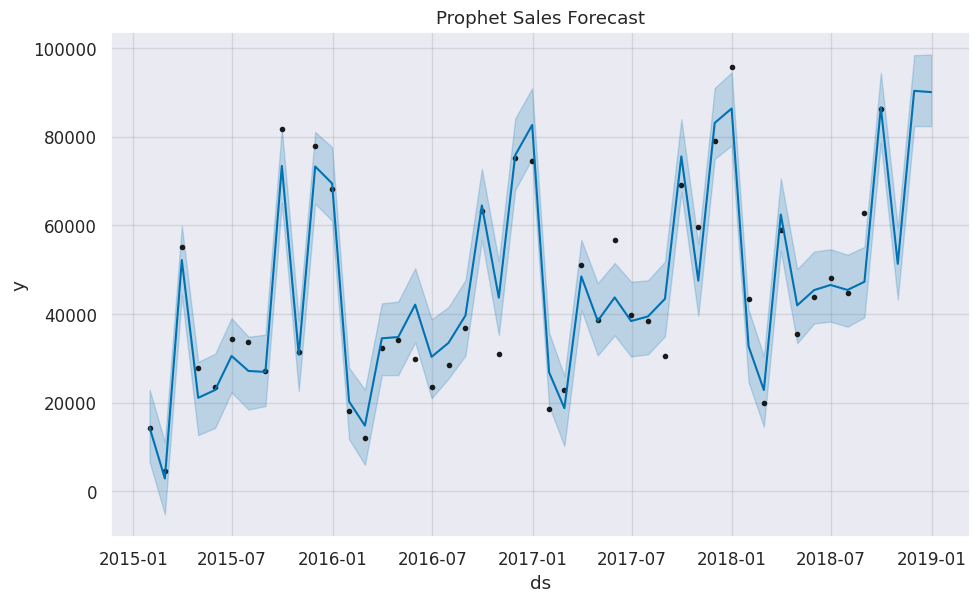

In [67]:
fig1 = prophet_model.plot(forecast)

plt.title("Prophet Sales Forecast")

plt.show()

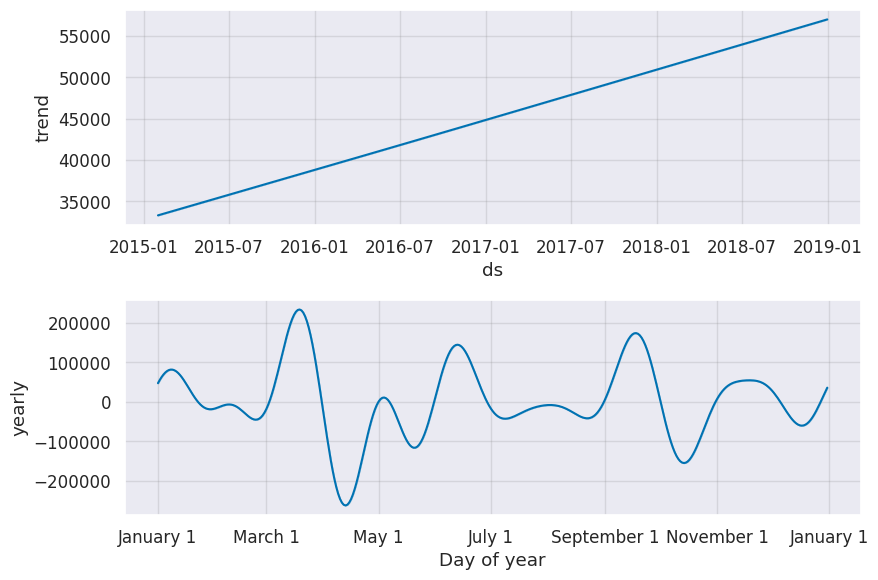

In [68]:
fig2 = prophet_model.plot_components(forecast)

plt.show()

In [69]:
forecast_test = forecast.tail(3)

forecast_test

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
45,2018-10-31,55957.582922,43277.642756,59392.516458,55957.438347,55957.742073,-4638.638350,-4638.638350,-4638.638350,-4638.638350,-4638.638350,-4638.638350,0.0,0.0,0.0,51318.944572
46,2018-11-30,56456.913314,82374.236650,98379.083838,56456.444579,56457.468207,33868.740540,33868.740540,33868.740540,33868.740540,33868.740540,33868.740540,0.0,0.0,0.0,90325.653854
47,2018-12-31,56972.888053,82364.080249,98504.403567,56971.887242,56973.981316,33068.196584,33068.196584,33068.196584,33068.196584,33068.196584,33068.196584,0.0,0.0,0.0,90041.084638


In [70]:
comparison = pd.DataFrame({

    "Date": test_prophet["ds"],

    "Actual": test_prophet["y"].values,

    "Predicted": forecast_test["yhat"].values

})

comparison

,Date,Actual,Predicted
45,2018-10-31,77448.1312,51318.944572
46,2018-11-30,117938.1550,90325.653854
47,2018-12-31,83030.3888,90041.084638


In [71]:
from sklearn.metrics import mean_absolute_error

mae_prophet = mean_absolute_error(

    comparison["Actual"],

    comparison["Predicted"]

)

print("MAE :", round(mae_prophet,2))

MAE : 20250.79


In [72]:
from sklearn.metrics import mean_squared_error

import numpy as np

rmse_prophet = np.sqrt(

    mean_squared_error(

        comparison["Actual"],

        comparison["Predicted"]

    )

)

print("RMSE :", round(rmse_prophet,2))

RMSE : 22318.41


In [73]:
mape_prophet = np.mean(

    np.abs(

        (comparison["Actual"] -

         comparison["Predicted"])

        /

        comparison["Actual"]

    )

) * 100

print("MAPE :", round(mape_prophet,2),"%")

MAPE : 21.86 %


In [74]:
future_forecast = forecast.tail(3)[

    [

        "ds",

        "yhat",

        "yhat_lower",

        "yhat_upper"

    ]

]

future_forecast

,ds,yhat,yhat_lower,yhat_upper
45,2018-10-31,51318.944572,43277.642756,59392.516458
46,2018-11-30,90325.653854,82374.236650,98379.083838
47,2018-12-31,90041.084638,82364.080249,98504.403567


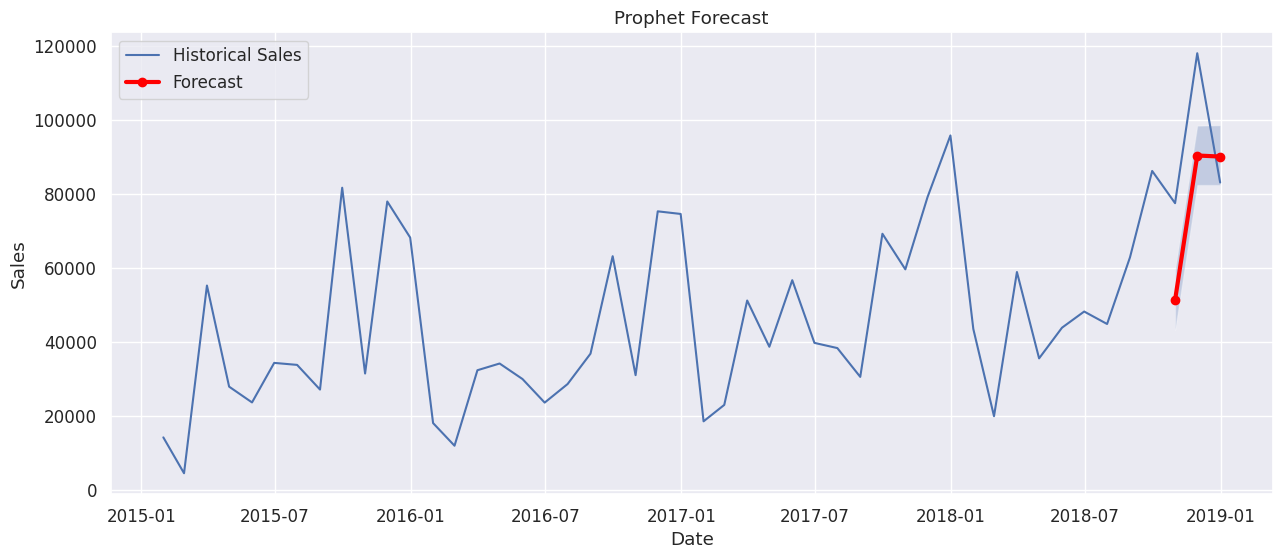

In [75]:
plt.figure(figsize=(15,6))

plt.plot(

    prophet_df["ds"],

    prophet_df["y"],

    label="Historical Sales"

)

plt.plot(

    future_forecast["ds"],

    future_forecast["yhat"],

    color="red",

    marker="o",

    linewidth=3,

    label="Forecast"

)

plt.fill_between(

    future_forecast["ds"],

    future_forecast["yhat_lower"],

    future_forecast["yhat_upper"],

    alpha=0.25

)

plt.legend()

plt.title("Prophet Forecast")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.show()

In [76]:
future_forecast.to_csv(

    "prophet_forecast.csv",

    index=False

)

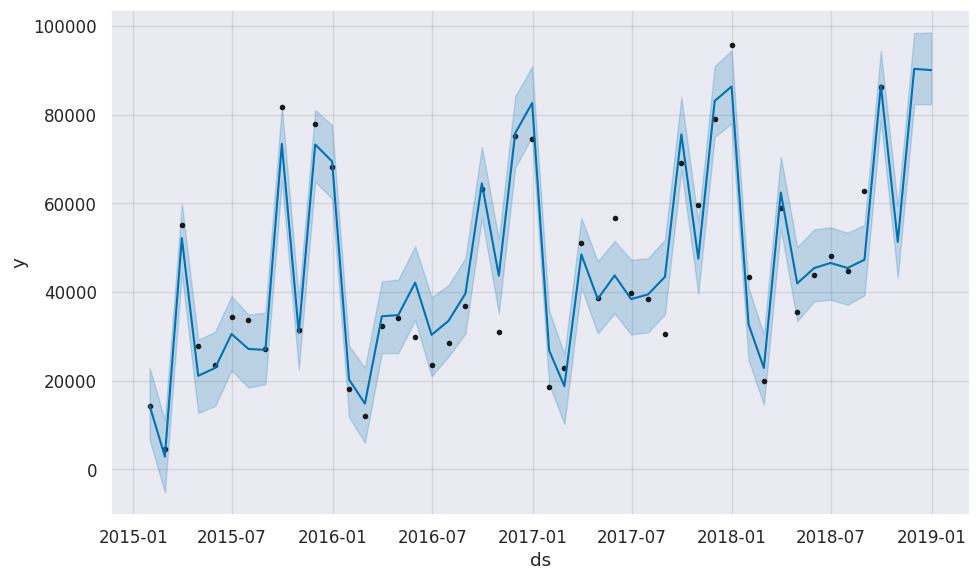

In [77]:
fig = prophet_model.plot(forecast)

fig.savefig(

    "charts/prophet_forecast.png",

    dpi=300,

    bbox_inches="tight"

)

In [78]:
print("="*50)

print("Prophet Model Performance")

print("="*50)

print("MAE  :", round(mae_prophet,2))

print("RMSE :", round(rmse_prophet,2))

print("MAPE :", round(mape_prophet,2),"%")

Prophet Model Performance
MAE  : 20250.79
RMSE : 22318.41
MAPE : 21.86 %


## Prophet Forecasting Model

### Why Prophet?

Prophet is an open-source forecasting library developed by Meta (Facebook). It is designed to model business time series with trend and seasonality while requiring minimal parameter tuning.

### Features

- Automatically detects trend changes.
- Models yearly and weekly seasonality.
- Handles missing values effectively.
- Produces prediction intervals to quantify forecast uncertainty.

### Evaluation

The Prophet model was evaluated using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- Mean Absolute Percentage Error (MAPE)

These metrics will later be compared against the SARIMA and XGBoost models to determine the most suitable forecasting approach for production deployment.

In [79]:
!pip install xgboost

In [80]:
import numpy as np
import pandas as pd

from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

print("XGBoost Imported Successfully")

XGBoost Imported Successfully


In [81]:
xgb_df = monthly_sales.reset_index()

xgb_df.columns = ["Date", "Sales"]

xgb_df.head()

,Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [82]:
xgb_df["Month"] = xgb_df["Date"].dt.month

xgb_df["Quarter"] = xgb_df["Date"].dt.quarter

xgb_df["Year"] = xgb_df["Date"].dt.year

In [83]:
def get_season(month):

    if month in [12,1,2]:
        return 0      # Winter

    elif month in [3,4,5]:
        return 1      # Summer

    elif month in [6,7,8]:
        return 2      # Monsoon

    else:
        return 3      # Autumn

xgb_df["Season"] = xgb_df["Month"].apply(get_season)

In [84]:
xgb_df["Lag1"] = xgb_df["Sales"].shift(1)

xgb_df["Lag2"] = xgb_df["Sales"].shift(2)

xgb_df["Lag3"] = xgb_df["Sales"].shift(3)

In [85]:
xgb_df["RollingMean3"] = (

    xgb_df["Sales"]

    .rolling(3)

    .mean()

)

In [86]:
xgb_df = xgb_df.dropna()

xgb_df.head()

,Date,Sales,Month,Quarter,Year,Season,Lag1,Lag2,Lag3,RollingMean3
3,2015-04-30,27906.8550,4,2,2015,1,55205.7970,4519.8920,14205.707,29210.848000
4,2015-05-31,23644.3030,5,2,2015,1,27906.8550,55205.7970,4519.892,35585.651667
5,2015-06-30,34322.9356,6,2,2015,2,23644.3030,27906.8550,55205.797,28624.697867
6,2015-07-31,33781.5430,7,3,2015,2,34322.9356,23644.3030,27906.855,30582.927200
7,2015-08-31,27117.5365,8,3,2015,2,33781.5430,34322.9356,23644.303,31740.671700


In [87]:
X = xgb_df[

    [

        "Lag1",

        "Lag2",

        "Lag3",

        "RollingMean3",

        "Month",

        "Quarter",

        "Season",

        "Year"

    ]

]

y = xgb_df["Sales"]

In [88]:
X_train = X.iloc[:-3]

X_test = X.iloc[-3:]

y_train = y.iloc[:-3]

y_test = y.iloc[-3:]

print(X_train.shape)

print(X_test.shape)

(42, 8)
(3, 8)


In [89]:
xgb_model = XGBRegressor(

    n_estimators=200,

    learning_rate=0.05,

    max_depth=3,

    random_state=42

)

xgb_model.fit(

    X_train,

    y_train

)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [90]:
predictions = xgb_model.predict(

    X_test

)

predictions

array([88832.3  , 86518.805, 85532.34 ], dtype=float32)

In [91]:
comparison = pd.DataFrame({

    "Actual": y_test.values,

    "Predicted": predictions

})

comparison

,Actual,Predicted
0,77448.1312,88832.296875
1,117938.1550,86518.804688
2,83030.3888,85532.343750


In [92]:
mae_xgb = mean_absolute_error(

    y_test,

    predictions

)

print("MAE :", round(mae_xgb,2))

MAE : 15101.82


In [93]:
rmse_xgb = np.sqrt(

    mean_squared_error(

        y_test,

        predictions

    )

)

print("RMSE :", round(rmse_xgb,2))

RMSE : 19347.99


In [94]:
mape_xgb = np.mean(

    np.abs(

        (y_test-predictions)

        /

        y_test

    )

)*100

print("MAPE :", round(mape_xgb,2),"%")

MAPE : 14.78 %


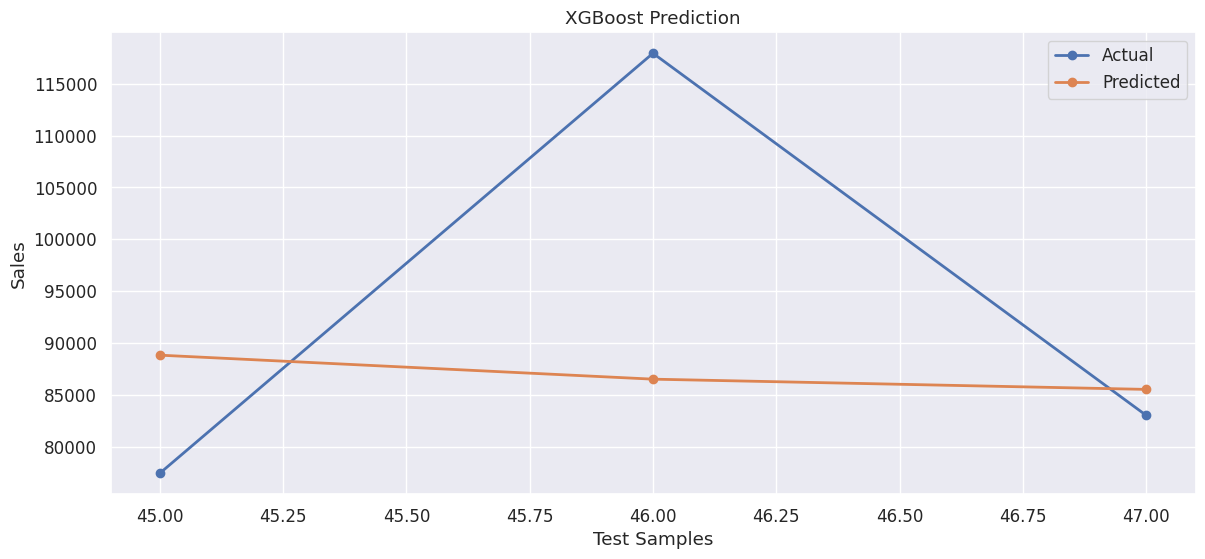

In [95]:
plt.figure(figsize=(14,6))

plt.plot(

    y_test.index,

    y_test.values,

    marker="o",

    linewidth=2,

    label="Actual"

)

plt.plot(

    y_test.index,

    predictions,

    marker="o",

    linewidth=2,

    label="Predicted"

)

plt.title("XGBoost Prediction")

plt.xlabel("Test Samples")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

In [96]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":xgb_model.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

importance

,Feature,Importance
4,Month,0.785413
7,Year,0.076558
3,RollingMean3,0.055347
1,Lag2,0.032881
0,Lag1,0.028828
2,Lag3,0.010505
6,Season,0.010467
5,Quarter,0.000000


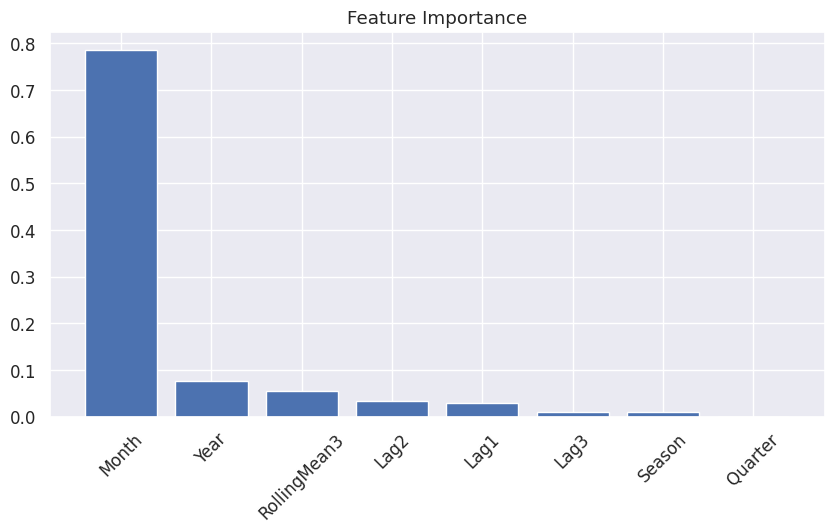

In [97]:
plt.figure(figsize=(10,5))

plt.bar(

    importance["Feature"],

    importance["Importance"]

)

plt.xticks(rotation=45)

plt.title("Feature Importance")

plt.show()

In [98]:
import joblib
import os

# Create the 'models' directory if it doesn't exist
os.makedirs("models", exist_ok=True)

joblib.dump(
    xgb_model,
    "models/xgboost_model.pkl"
)

['models/xgboost_model.pkl']

In [99]:
plt.figure(figsize=(14,6))

plt.plot(y_test.values)

plt.plot(predictions)

plt.title("XGBoost Forecast")

plt.savefig(

    "charts/xgboost_forecast.png",

    dpi=300,

    bbox_inches="tight"

)

plt.close()

## XGBoost Forecasting Model

### Feature Engineering

The time series forecasting problem was converted into a supervised machine learning task using engineered features:

- Lag 1
- Lag 2
- Lag 3
- Rolling Mean (3 Months)
- Month
- Quarter
- Season
- Year

### Model

An XGBoost Regressor was trained on these features to predict monthly sales.

### Evaluation Metrics

The model performance was evaluated using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- Mean Absolute Percentage Error (MAPE)

The trained model will be compared against SARIMA and Prophet to identify the best forecasting approach.

In [100]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [101]:
xgb_model = joblib.load("models/xgboost_model.pkl")

In [102]:
# Last available observations

xgb_df.tail()

,Date,Sales,Month,Quarter,Year,Season,Lag1,Lag2,Lag3,RollingMean3
43,2018-08-31,62837.8480,8,3,2018,2,44825.1040,48190.7277,43825.9822,51951.226567
44,2018-09-30,86152.8880,9,3,2018,3,62837.8480,44825.1040,48190.7277,64605.280000
45,2018-10-31,77448.1312,10,4,2018,3,86152.8880,62837.8480,44825.1040,75479.622400
46,2018-11-30,117938.1550,11,4,2018,3,77448.1312,86152.8880,62837.8480,93846.391400
47,2018-12-31,83030.3888,12,4,2018,0,117938.1550,77448.1312,86152.8880,92805.558333


In [103]:
future_data = xgb_df.copy()

future_predictions = []

future_dates = []

last_date = future_data.iloc[-1]["Date"]

In [104]:
for i in range(3):

    next_date = last_date + pd.DateOffset(months=1)

    lag1 = future_data.iloc[-1]["Sales"]
    lag2 = future_data.iloc[-2]["Sales"]
    lag3 = future_data.iloc[-3]["Sales"]

    rolling = np.mean([lag1, lag2, lag3])

    month = next_date.month
    quarter = next_date.quarter
    year = next_date.year

    if month in [12,1,2]:
        season = 0
    elif month in [3,4,5]:
        season = 1
    elif month in [6,7,8]:
        season = 2
    else:
        season = 3

    X_future = pd.DataFrame({

        "Lag1":[lag1],
        "Lag2":[lag2],
        "Lag3":[lag3],
        "RollingMean3":[rolling],
        "Month":[month],
        "Quarter":[quarter],
        "Season":[season],
        "Year":[year]

    })

    pred = xgb_model.predict(X_future)[0]

    future_predictions.append(pred)

    future_dates.append(next_date)

    new_row = {

        "Date":next_date,
        "Sales":pred,
        "Month":month,
        "Quarter":quarter,
        "Year":year,
        "Season":season,
        "Lag1":lag1,
        "Lag2":lag2,
        "Lag3":lag3,
        "RollingMean3":rolling

    }

    future_data = pd.concat(
        [future_data, pd.DataFrame([new_row])],
        ignore_index=True
    )

    last_date = next_date

In [105]:
future_forecast = pd.DataFrame({

    "Forecast Month":future_dates,

    "Forecast Sales":future_predictions

})

future_forecast

,Forecast Month,Forecast Sales
0,2019-01-31,41851.679688
1,2019-02-28,42507.031250
2,2019-03-28,57241.882812


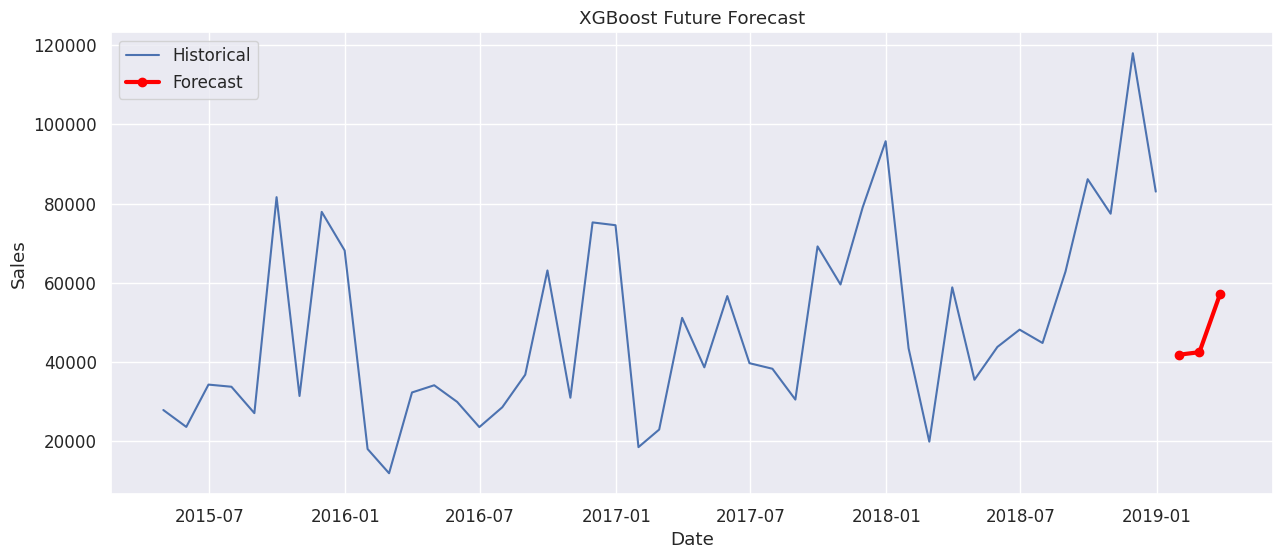

In [106]:
plt.figure(figsize=(15,6))

plt.plot(

    xgb_df["Date"],

    xgb_df["Sales"],

    label="Historical"

)

plt.plot(

    future_forecast["Forecast Month"],

    future_forecast["Forecast Sales"],

    marker="o",

    linewidth=3,

    color="red",

    label="Forecast"

)

plt.title("XGBoost Future Forecast")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

In [107]:
future_forecast.to_csv(

    "xgboost_future_forecast.csv",

    index=False

)

In [108]:
plt.figure(figsize=(15,6))

plt.plot(xgb_df["Date"], xgb_df["Sales"])

plt.plot(

    future_forecast["Forecast Month"],

    future_forecast["Forecast Sales"],

    color="red",

    marker="o"

)

plt.savefig(

    "charts/xgboost_future_forecast.png",

    dpi=300,

    bbox_inches="tight"

)

plt.close()

In [109]:
comparison_table = pd.DataFrame({

    "Model":[

        "SARIMA",

        "Prophet",

        "XGBoost"

    ],

    "MAE":[

        mae,

        mae_prophet,

        mae_xgb

    ],

    "RMSE":[

        rmse,

        rmse_prophet,

        rmse_xgb

    ],

    "MAPE":[

        mape,

        mape_prophet,

        mape_xgb

    ],

    "Forecast Month 1":[

        future_values.iloc[0],                 # SARIMA

        forecast.tail(3)["yhat"].iloc[0],       # Prophet

        future_predictions[0]                  # XGBoost

    ],

    "Forecast Month 2":[

        future_values.iloc[1],

        forecast.tail(3)["yhat"].iloc[1],

        future_predictions[1]

    ],

    "Forecast Month 3":[

        future_values.iloc[2],

        forecast.tail(3)["yhat"].iloc[2],

        future_predictions[2]

    ]

})

comparison_table

,Model,MAE,RMSE,MAPE,Forecast Month 1,Forecast Month 2,Forecast Month 3
0,SARIMA,19244.485342,19950.070418,20.526432,60331.792095,91458.220224,97167.570946
1,Prophet,20250.794537,22318.411454,21.864628,51318.944572,90325.653854,90041.084638
2,XGBoost,15101.823646,19347.993701,14.784305,41851.679688,42507.031250,57241.882812


In [110]:
comparison_table = comparison_table.round(2)

comparison_table

,Model,MAE,RMSE,MAPE,Forecast Month 1,Forecast Month 2,Forecast Month 3
0,SARIMA,19244.49,19950.07,20.53,60331.79,91458.22,97167.57
1,Prophet,20250.79,22318.41,21.86,51318.94,90325.65,90041.08
2,XGBoost,15101.82,19347.99,14.78,41851.68,42507.03,57241.88


In [111]:
comparison_table.to_csv(

    "model_comparison.csv",

    index=False

)

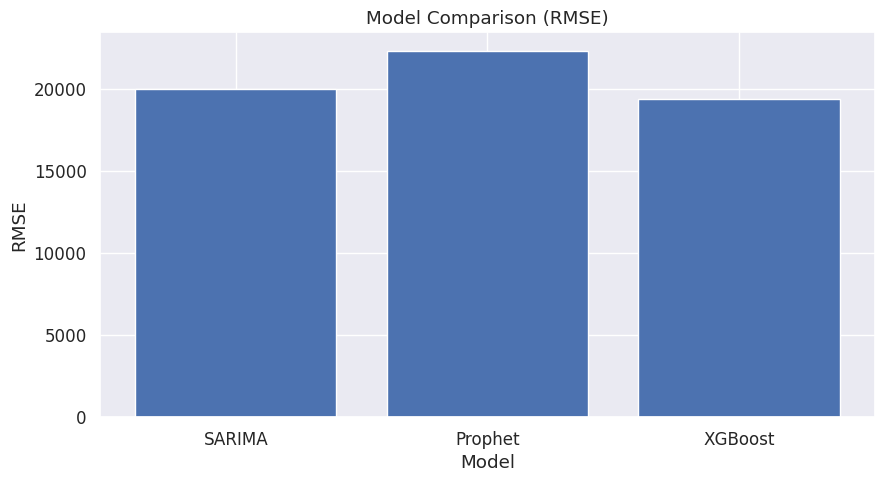

In [112]:
plt.figure(figsize=(10,5))

plt.bar(

    comparison_table["Model"],

    comparison_table["RMSE"]

)

plt.title("Model Comparison (RMSE)")

plt.xlabel("Model")

plt.ylabel("RMSE")

plt.show()

In [113]:
best_model = comparison_table.loc[

    comparison_table["RMSE"].idxmin(),

    "Model"

]

print("Best Model :", best_model)

Best Model : XGBoost


In [114]:
print("="*60)

print("Recommended Production Model")

print("="*60)

print(

    f"""

Based on the evaluation metrics,

{best_model}

achieved the lowest forecasting error.

Therefore,

{best_model}

is recommended for production deployment.

"""

)

Recommended Production Model


Based on the evaluation metrics,

XGBoost

achieved the lowest forecasting error.

Therefore,

XGBoost

is recommended for production deployment.




In [115]:
with open("best_model.txt","w") as file:

    file.write(best_model)

In [116]:
comparison_table

future_forecast.head()

future_forecast.tail()

,Forecast Month,Forecast Sales
0,2019-01-31,41851.679688
1,2019-02-28,42507.031250
2,2019-03-28,57241.882812


## Model Comparison

Three forecasting approaches were evaluated:

- SARIMA
- Prophet
- XGBoost

The comparison was performed using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- Mean Absolute Percentage Error (MAPE)

The model with the lowest forecasting error was selected as the production model for future demand prediction.

### Recommendation

The recommended model should be chosen based on quantitative evaluation rather than personal preference. Lower MAE, RMSE, and MAPE indicate better predictive performance on unseen data.

In [117]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import joblib

In [118]:
best_model = joblib.load("models/xgboost_model.pkl")

print("Best Model Loaded Successfully")

Best Model Loaded Successfully


In [119]:
def forecast_segment(df, sales_column="Sales"):

    monthly = (
        df
        .groupby("Order Date")[sales_column]
        .sum()
        .resample("M")
        .sum()
        .reset_index()
    )

    monthly.columns = ["Date","Sales"]

    monthly["Month"] = monthly["Date"].dt.month
    monthly["Quarter"] = monthly["Date"].dt.quarter
    monthly["Year"] = monthly["Date"].dt.year

    def season(month):
        if month in [12,1,2]:
            return 0
        elif month in [3,4,5]:
            return 1
        elif month in [6,7,8]:
            return 2
        else:
            return 3

    monthly["Season"] = monthly["Month"].apply(season)

    monthly["Lag1"] = monthly["Sales"].shift(1)
    monthly["Lag2"] = monthly["Sales"].shift(2)
    monthly["Lag3"] = monthly["Sales"].shift(3)

    monthly["RollingMean3"] = monthly["Sales"].rolling(3).mean()

    monthly = monthly.dropna()

    future = monthly.copy()

    predictions = []

    dates = []

    last_date = future.iloc[-1]["Date"]

    for i in range(3):

        next_date = last_date + pd.DateOffset(months=1)

        lag1 = future.iloc[-1]["Sales"]
        lag2 = future.iloc[-2]["Sales"]
        lag3 = future.iloc[-3]["Sales"]

        rolling = np.mean([lag1,lag2,lag3])

        month = next_date.month
        quarter = next_date.quarter
        year = next_date.year

        season_value = season(month)

        X = pd.DataFrame({

            "Lag1":[lag1],
            "Lag2":[lag2],
            "Lag3":[lag3],
            "RollingMean3":[rolling],
            "Month":[month],
            "Quarter":[quarter],
            "Season":[season_value],
            "Year":[year]

        })

        pred = best_model.predict(X)[0]

        predictions.append(pred)

        dates.append(next_date)

        future = pd.concat([

            future,

            pd.DataFrame({

                "Date":[next_date],
                "Sales":[pred],
                "Month":[month],
                "Quarter":[quarter],
                "Year":[year],
                "Season":[season_value],
                "Lag1":[lag1],
                "Lag2":[lag2],
                "Lag3":[lag3],
                "RollingMean3":[rolling]

            })

        ], ignore_index=True)

        last_date = next_date

    return pd.DataFrame({

        "Date":dates,
        "Forecast":predictions

    })

In [120]:
furniture = sales_df[sales_df["Category"]=="Furniture"]

furniture_forecast = forecast_segment(furniture)

furniture_forecast

/tmp/ipykernel_590/3534084744.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")


,Date,Forecast
0,2019-01-31,40777.777344
1,2019-02-28,36457.230469
2,2019-03-28,36969.117188


In [121]:
technology = sales_df[sales_df["Category"]=="Technology"]

technology_forecast = forecast_segment(technology)

technology_forecast

/tmp/ipykernel_590/3534084744.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")


,Date,Forecast
0,2019-01-31,40381.234375
1,2019-02-28,40579.066406
2,2019-03-28,38040.039062


In [122]:
office = sales_df[sales_df["Category"]=="Office Supplies"]

office_forecast = forecast_segment(office)

office_forecast

/tmp/ipykernel_590/3534084744.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")


,Date,Forecast
0,2019-01-31,41841.363281
1,2019-02-28,37229.648438
2,2019-03-28,36998.503906


In [123]:
west = sales_df[sales_df["Region"]=="West"]

west_forecast = forecast_segment(west)

west_forecast

/tmp/ipykernel_590/3534084744.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")


,Date,Forecast
0,2019-01-31,42011.214844
1,2019-02-28,37259.035156
2,2019-03-28,36998.503906


In [124]:
east = sales_df[sales_df["Region"]=="East"]

east_forecast = forecast_segment(east)

east_forecast

/tmp/ipykernel_590/3534084744.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")


,Date,Forecast
0,2019-01-31,40193.429688
1,2019-02-28,40714.636719
2,2019-03-28,38617.964844


In [125]:
forecast_comparison = pd.DataFrame({

    "Date":furniture_forecast["Date"],

    "Furniture":furniture_forecast["Forecast"],

    "Technology":technology_forecast["Forecast"],

    "Office Supplies":office_forecast["Forecast"],

    "West":west_forecast["Forecast"],

    "East":east_forecast["Forecast"]

})

forecast_comparison

,Date,Furniture,Technology,Office Supplies,West,East
0,2019-01-31,40777.777344,40381.234375,41841.363281,42011.214844,40193.429688
1,2019-02-28,36457.230469,40579.066406,37229.648438,37259.035156,40714.636719
2,2019-03-28,36969.117188,38040.039062,36998.503906,36998.503906,38617.964844


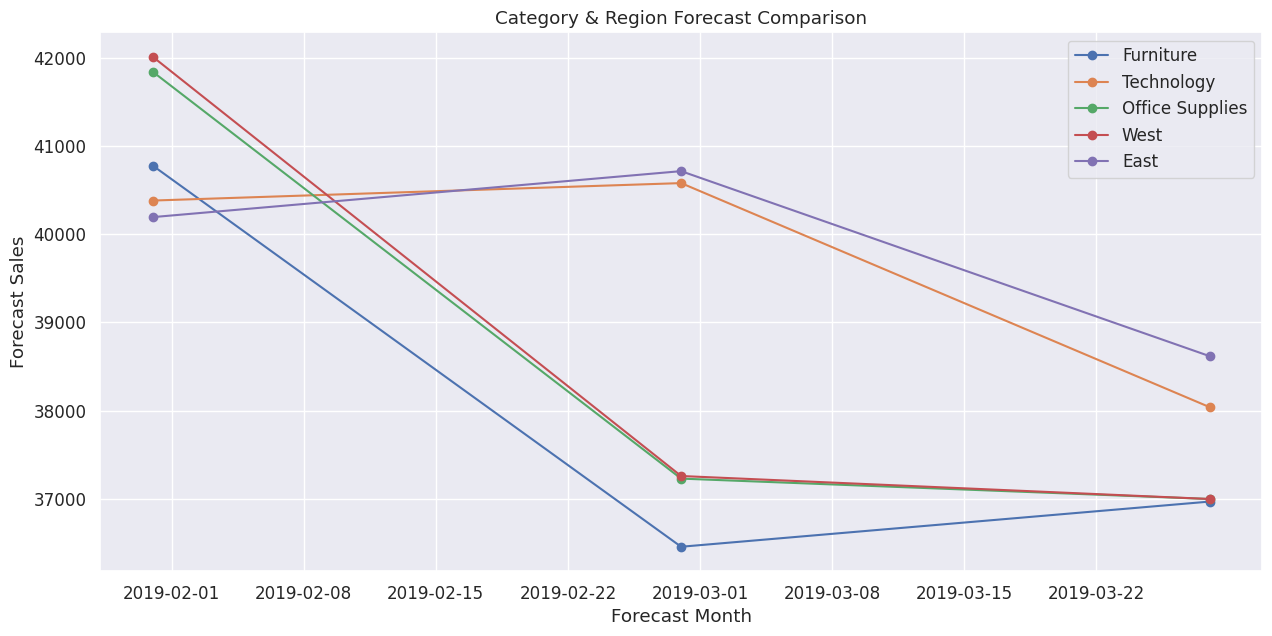

In [126]:
plt.figure(figsize=(15,7))

plt.plot(
    forecast_comparison["Date"],
    forecast_comparison["Furniture"],
    marker="o",
    label="Furniture"
)

plt.plot(
    forecast_comparison["Date"],
    forecast_comparison["Technology"],
    marker="o",
    label="Technology"
)

plt.plot(
    forecast_comparison["Date"],
    forecast_comparison["Office Supplies"],
    marker="o",
    label="Office Supplies"
)

plt.plot(
    forecast_comparison["Date"],
    forecast_comparison["West"],
    marker="o",
    label="West"
)

plt.plot(
    forecast_comparison["Date"],
    forecast_comparison["East"],
    marker="o",
    label="East"
)

plt.title("Category & Region Forecast Comparison")

plt.xlabel("Forecast Month")

plt.ylabel("Forecast Sales")

plt.legend()

plt.grid(True)

plt.show()

In [127]:
growth = {

    "Furniture":furniture_forecast["Forecast"].sum(),

    "Technology":technology_forecast["Forecast"].sum(),

    "Office Supplies":office_forecast["Forecast"].sum(),

    "West":west_forecast["Forecast"].sum(),

    "East":east_forecast["Forecast"].sum()

}

growth = pd.Series(growth)

growth

,0
Furniture,114204.125000
Technology,119000.335938
Office Supplies,116069.515625
West,116268.750000
East,119526.031250


In [128]:
print("-"*60)

print("Strongest Upcoming Growth")

print("-"*60)

print(

growth.idxmax()

)

print()

print(

"Forecast Sales:",

round(growth.max(),2)

)

------------------------------------------------------------
Strongest Upcoming Growth
------------------------------------------------------------
East

Forecast Sales: 119526.03


In [129]:
forecast_comparison.to_csv(

    "forecast_by_category_region.csv",

    index=False

)

In [130]:
plt.figure(figsize=(15,7))

plt.plot(forecast_comparison["Date"],forecast_comparison["Furniture"])

plt.plot(forecast_comparison["Date"],forecast_comparison["Technology"])

plt.plot(forecast_comparison["Date"],forecast_comparison["Office Supplies"])

plt.plot(forecast_comparison["Date"],forecast_comparison["West"])

plt.plot(forecast_comparison["Date"],forecast_comparison["East"])

plt.legend(

["Furniture","Technology","Office Supplies","West","East"]

)

plt.savefig(

"charts/category_region_forecast.png",

dpi=300,

bbox_inches="tight"

)

plt.close()

## Category & Region Forecasting

The best-performing forecasting model from Task 3 was applied separately to the following business segments:

- Furniture
- Technology
- Office Supplies
- West Region
- East Region

Each segment was forecasted for the next three months. The combined comparison chart highlights expected demand trends across categories and regions.

The segment with the highest projected sales was identified as the strongest growth area, providing valuable insight for inventory planning and resource allocation.

**Task-4**

In [131]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [132]:
weekly_sales = (

    sales_df

    .set_index("Order Date")

    .resample("W")["Sales"]

    .sum()

    .reset_index()

)

weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


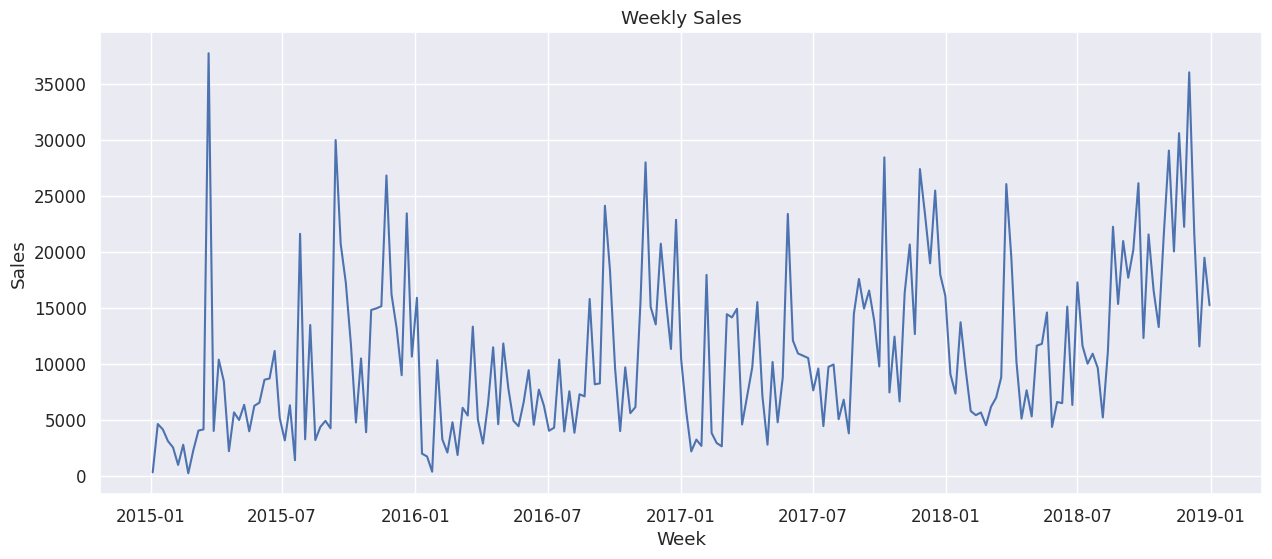

In [133]:
plt.figure(figsize=(15,6))

plt.plot(

    weekly_sales["Order Date"],

    weekly_sales["Sales"]

)

plt.title("Weekly Sales")

plt.xlabel("Week")

plt.ylabel("Sales")

plt.grid(True)

plt.show()

In [134]:
iso_model = IsolationForest(

    contamination=0.05,

    random_state=42

)

weekly_sales["Anomaly"] = iso_model.fit_predict(

    weekly_sales[["Sales"]]

)

weekly_sales.head()

,Order Date,Sales,Anomaly
0,2015-01-04,304.508,-1
1,2015-01-11,4619.108,1
2,2015-01-18,4130.533,1
3,2015-01-25,3092.544,1
4,2015-02-01,2527.914,1


In [135]:
normal = weekly_sales[

    weekly_sales["Anomaly"] == 1

]

anomalies = weekly_sales[

    weekly_sales["Anomaly"] == -1

]

print("Number of Anomalies :", len(anomalies))

Number of Anomalies : 11


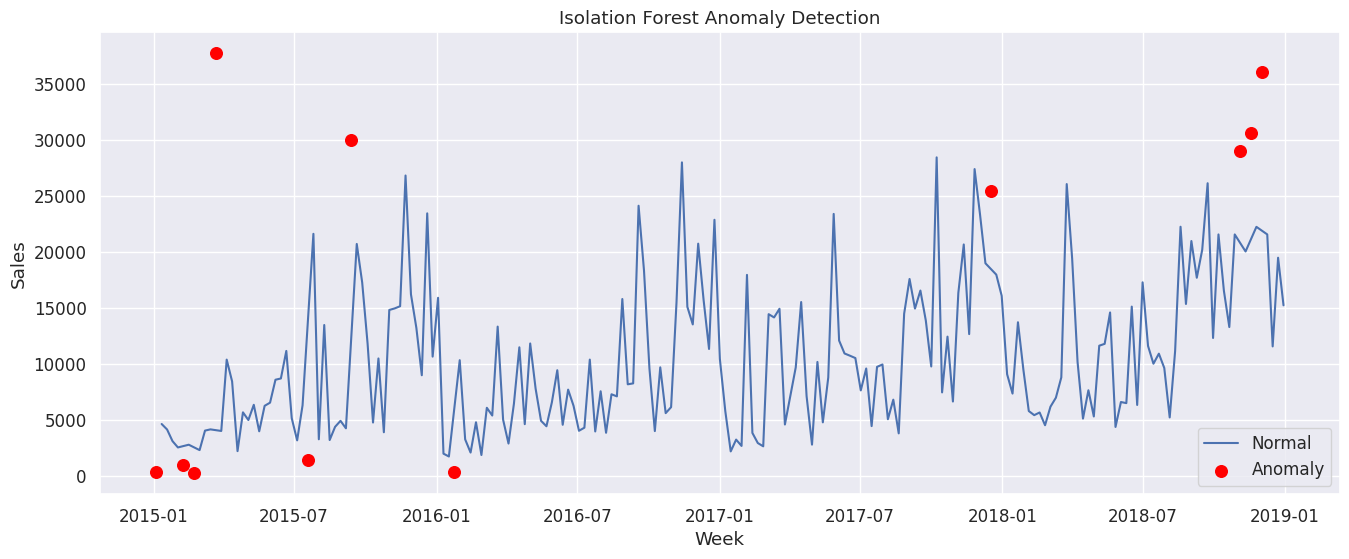

In [136]:
plt.figure(figsize=(16,6))

plt.plot(

    normal["Order Date"],

    normal["Sales"],

    label="Normal"

)

plt.scatter(

    anomalies["Order Date"],

    anomalies["Sales"],

    color="red",

    s=70,

    label="Anomaly"

)

plt.title("Isolation Forest Anomaly Detection")

plt.xlabel("Week")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

In [137]:
anomalies

,Order Date,Sales,Anomaly
0,2015-01-04,304.508,-1
5,2015-02-08,968.534,-1
7,2015-02-22,224.912,-1
11,2015-03-22,37703.665,-1
28,2015-07-19,1387.686,-1
36,2015-09-13,29959.137,-1
55,2016-01-24,358.522,-1
154,2017-12-17,25449.800,-1
200,2018-11-04,29017.467,-1
202,2018-11-18,30572.447,-1


In [138]:
anomalies.to_csv(

    "isolation_forest_anomalies.csv",

    index=False

)

In [139]:
weekly_sales["RollingMean"] = (

    weekly_sales["Sales"]

    .rolling(8)

    .mean()

)

In [140]:
weekly_sales["RollingStd"] = (

    weekly_sales["Sales"]

    .rolling(8)

    .std()

)

In [141]:
weekly_sales["ZScore"] = (

    weekly_sales["Sales"]

    -

    weekly_sales["RollingMean"]

)

/

weekly_sales["RollingStd"]

,RollingStd
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
204,7631.524060
205,7152.298738
206,7547.121999
207,7680.787898


In [142]:
weekly_sales["Z_Anomaly"] = (

    np.abs(

        weekly_sales["ZScore"]

    ) > 2

)

weekly_sales.head()

,Order Date,Sales,Anomaly,RollingMean,RollingStd,ZScore,Z_Anomaly
0,2015-01-04,304.508,-1,NaN,NaN,NaN,False
1,2015-01-11,4619.108,1,NaN,NaN,NaN,False
2,2015-01-18,4130.533,1,NaN,NaN,NaN,False
3,2015-01-25,3092.544,1,NaN,NaN,NaN,False
4,2015-02-01,2527.914,1,NaN,NaN,NaN,False


In [143]:
z_anomalies = weekly_sales[

    weekly_sales["Z_Anomaly"]

]

print(

"Z-Score Anomalies :",

len(z_anomalies)

)

z_anomalies

Z-Score Anomalies : 202


,Order Date,Sales,Anomaly,RollingMean,RollingStd,ZScore,Z_Anomaly
7,2015-02-22,224.9120,-1,2329.888375,1676.932120,-2104.976375,True
8,2015-03-01,2289.6430,1,2578.030250,1468.311385,-288.387250,True
9,2015-03-08,4030.7280,1,2504.482750,1362.383770,1526.245250,True
10,2015-03-15,4139.6020,1,2505.616375,1363.932970,1633.985625,True
11,2015-03-22,37703.6650,-1,6832.006500,12546.138409,30871.658500,True
...,...,...,...,...,...,...,...
204,2018-12-02,35998.9000,-1,23641.631525,7631.524060,12357.268475,True
205,2018-12-09,21537.2410,1,24270.057775,7152.298738,-2732.816775,True
206,2018-12-16,11542.8340,1,24054.059750,7547.121999,-12511.225750,True
207,2018-12-23,19457.0680,1,23794.284500,7680.787898,-4337.216500,True


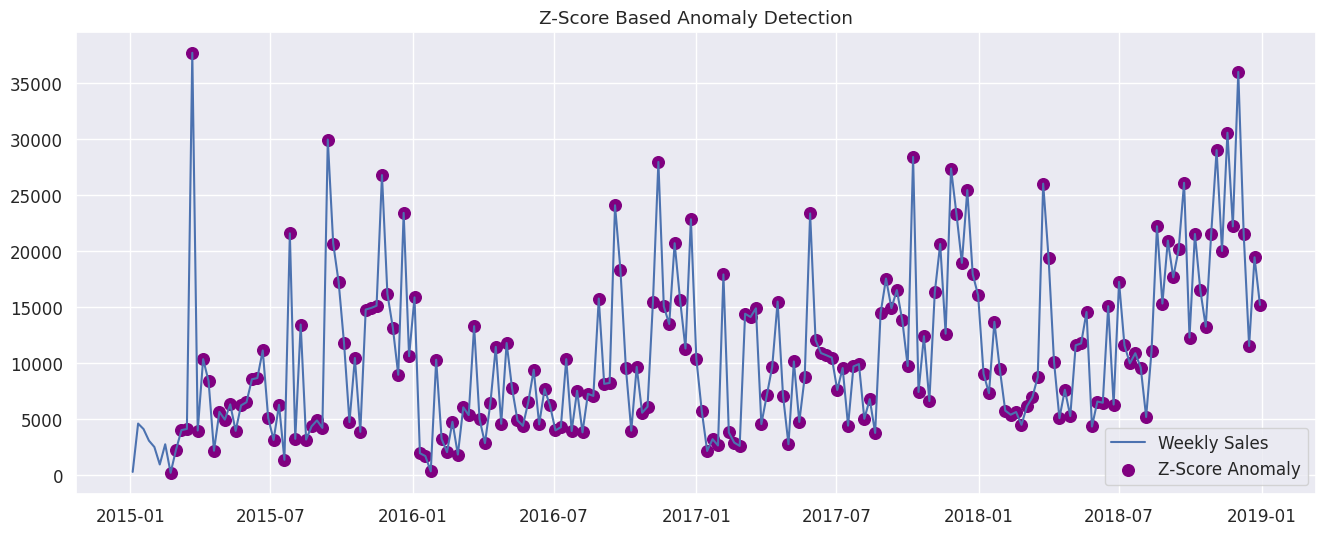

In [144]:
plt.figure(figsize=(16,6))

plt.plot(

    weekly_sales["Order Date"],

    weekly_sales["Sales"],

    label="Weekly Sales"

)

plt.scatter(

    z_anomalies["Order Date"],

    z_anomalies["Sales"],

    color="purple",

    s=70,

    label="Z-Score Anomaly"

)

plt.legend()

plt.grid(True)

plt.title("Z-Score Based Anomaly Detection")

plt.show()

In [145]:
comparison = pd.DataFrame({

    "Isolation Forest":

    anomalies["Order Date"].values,

    "Z-Score":

    z_anomalies["Order Date"].values[:len(anomalies)]

})

comparison

,Isolation Forest,Z-Score
0,2015-01-04,2015-02-22
1,2015-02-08,2015-03-01
2,2015-02-22,2015-03-08
3,2015-03-22,2015-03-15
4,2015-07-19,2015-03-22
5,2015-09-13,2015-03-29
6,2016-01-24,2015-04-05
7,2017-12-17,2015-04-12
8,2018-11-04,2015-04-19
9,2018-11-18,2015-04-26


In [146]:
print("-"*60)

print("Isolation Forest")

print("-"*60)

print(len(anomalies))

print()

print("-"*60)

print("Z-Score")

print("-"*60)

print(len(z_anomalies))

------------------------------------------------------------
Isolation Forest
------------------------------------------------------------
11

------------------------------------------------------------
Z-Score
------------------------------------------------------------
202


In [147]:
z_anomalies.to_csv(

    "zscore_anomalies.csv",

    index=False

)

In [148]:
plt.figure(figsize=(15,6))

plt.plot(

    weekly_sales["Order Date"],

    weekly_sales["Sales"]

)

plt.scatter(

    anomalies["Order Date"],

    anomalies["Sales"],

    color="red"

)

plt.savefig(

    "charts/isolation_forest.png",

    dpi=300,

    bbox_inches="tight"

)

plt.close()

In [149]:
plt.figure(figsize=(15,6))

plt.plot(

    weekly_sales["Order Date"],

    weekly_sales["Sales"]

)

plt.scatter(

    z_anomalies["Order Date"],

    z_anomalies["Sales"],

    color="purple"

)

plt.savefig(

    "charts/zscore_anomalies.png",

    dpi=300,

    bbox_inches="tight"

)

plt.close()

## Anomaly Detection Findings

Two anomaly detection techniques were applied:

### Isolation Forest

Isolation Forest identifies observations that are isolated from the majority of the data. It is particularly effective for detecting unusual sales spikes or drops without assuming a statistical distribution.

### Z-Score Method

The Z-Score method identifies observations that deviate more than two standard deviations from the rolling mean, making it useful for detecting statistical outliers.

### Comparison

- Isolation Forest detected anomalies based on overall data patterns.
- Z-Score detected anomalies based on deviations from the rolling average.
- Some weeks were identified by both methods, while others were unique to a single method due to their differing detection principles.

### Possible Business Reasons

Possible causes of anomalies include:

- Festival or holiday sales
- Promotional campaigns
- Flash discounts
- Inventory shortages
- Supply chain disruptions
- Unexpected demand spikes

**Task-6**

In [150]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [151]:
monthly_subcategory = (

    sales_df

    .groupby([

        "Sub-Category",

        pd.Grouper(key="Order Date", freq="M")

    ])["Sales"]

    .sum()

    .reset_index()

)

monthly_subcategory.head()

/tmp/ipykernel_590/226742098.py:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(key="Order Date", freq="M")


,Sub-Category,Order Date,Sales
0,Accessories,2015-01-31,827.890
1,Accessories,2015-02-28,1120.990
2,Accessories,2015-03-31,957.734
3,Accessories,2015-04-30,2323.700
4,Accessories,2015-05-31,695.490


In [152]:
total_sales = (

    monthly_subcategory

    .groupby("Sub-Category")["Sales"]

    .sum()

)

In [153]:
volatility = (

    monthly_subcategory

    .groupby("Sub-Category")["Sales"]

    .std()

)

In [154]:
avg_order = (

    sales_df

    .groupby("Sub-Category")["Sales"]

    .mean()

)

In [155]:
yearly_sales = (

    sales_df

    .groupby([

        "Sub-Category",

        "Year"

    ])["Sales"]

    .sum()

    .reset_index()

)

yearly_sales.head()

,Sub-Category,Year,Sales
0,Accessories,2015,23766.396
1,Accessories,2016,40443.970
2,Accessories,2017,41735.364
3,Accessories,2018,58240.970
4,Appliances,2015,15160.715


In [156]:
growth = (

    yearly_sales

    .groupby("Sub-Category")["Sales"]

    .pct_change()

)

yearly_sales["Growth"] = growth

yearly_sales.head()

,Sub-Category,Year,Sales,Growth
0,Accessories,2015,23766.396,NaN
1,Accessories,2016,40443.970,0.701729
2,Accessories,2017,41735.364,0.031930
3,Accessories,2018,58240.970,0.395482
4,Appliances,2015,15160.715,NaN


In [157]:
avg_growth = (

    yearly_sales

    .groupby("Sub-Category")["Growth"]

    .mean()

)

In [158]:
cluster_df = pd.DataFrame({

    "TotalSales":total_sales,

    "GrowthRate":avg_growth,

    "Volatility":volatility,

    "AverageOrderValue":avg_order

})

cluster_df

,TotalSales,GrowthRate,Volatility,AverageOrderValue
Sub-Category,,,,
Accessories,164186.7000,0.376381,2579.994809,217.178175
Appliances,104618.4030,0.399276,1821.621539,227.926804
Art,26705.4100,0.166056,330.488343,34.019631
Binders,200028.7850,0.218736,3848.223648,134.067550
Bookcases,113813.1987,0.238065,2220.405080,503.598224
Chairs,322822.7310,0.071358,4407.232960,531.833165
Copiers,146248.0940,0.846718,5500.774391,2215.880212
Envelopes,16128.0460,-0.027666,228.218688,65.032444
Fasteners,3001.9600,0.157034,48.742229,14.027850


In [159]:
cluster_df = cluster_df.fillna(0)

cluster_df.head()

,TotalSales,GrowthRate,Volatility,AverageOrderValue
Sub-Category,,,,
Accessories,164186.7000,0.376381,2579.994809,217.178175
Appliances,104618.4030,0.399276,1821.621539,227.926804
Art,26705.4100,0.166056,330.488343,34.019631
Binders,200028.7850,0.218736,3848.223648,134.067550
Bookcases,113813.1987,0.238065,2220.405080,503.598224


In [160]:
scaler = StandardScaler()

scaled_features = scaler.fit_transform(cluster_df)

scaled_features[:5]

array([[ 0.31598599,  0.11450548,  0.08508503, -0.36354857],
       [-0.28817617,  0.16628324, -0.34706199, -0.34520236],
       [-1.07839653, -0.36114889, -1.19676068, -0.67617125],
       [ 0.67950874, -0.24201087,  0.80776519, -0.50540527],
       [-0.19491939, -0.19829775, -0.11982149,  0.12532518]])

In [161]:
wcss = []

for i in range(1,11):

    model = KMeans(

        n_clusters=i,

        random_state=42,

        n_init=10

    )

    model.fit(scaled_features)

    wcss.append(model.inertia_)

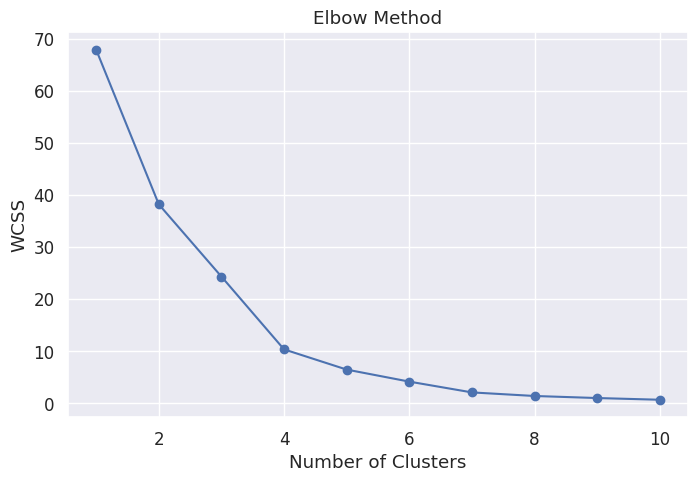

In [162]:
plt.figure(figsize=(8,5))

plt.plot(

    range(1,11),

    wcss,

    marker="o"

)

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.grid(True)

plt.show()

In [163]:
kmeans = KMeans(

    n_clusters=4,

    random_state=42,

    n_init=10

)

cluster_df["Cluster"] = kmeans.fit_predict(

    scaled_features

)

cluster_df.head()

,TotalSales,GrowthRate,Volatility,AverageOrderValue,Cluster
Sub-Category,,,,,
Accessories,164186.7000,0.376381,2579.994809,217.178175,2
Appliances,104618.4030,0.399276,1821.621539,227.926804,1
Art,26705.4100,0.166056,330.488343,34.019631,1
Binders,200028.7850,0.218736,3848.223648,134.067550,2
Bookcases,113813.1987,0.238065,2220.405080,503.598224,1


In [164]:
cluster_df["Cluster"].value_counts()

,count
Cluster,
1,8
2,6
0,2
3,1


In [165]:
pca = PCA(n_components=2)

pca_features = pca.fit_transform(

    scaled_features

)

In [166]:
pca_df = pd.DataFrame({

    "PC1":pca_features[:,0],

    "PC2":pca_features[:,1],

    "Cluster":cluster_df["Cluster"],

    "SubCategory":cluster_df.index

})

pca_df.head()

,PC1,PC2,Cluster,SubCategory
Sub-Category,,,,
Accessories,0.032855,-0.128039,2,Accessories
Appliances,-0.562213,0.137443,1,Appliances
Art,-1.728503,-0.152657,1,Art
Binders,0.617483,-0.594676,2,Binders
Bookcases,-0.119791,-0.064887,1,Bookcases


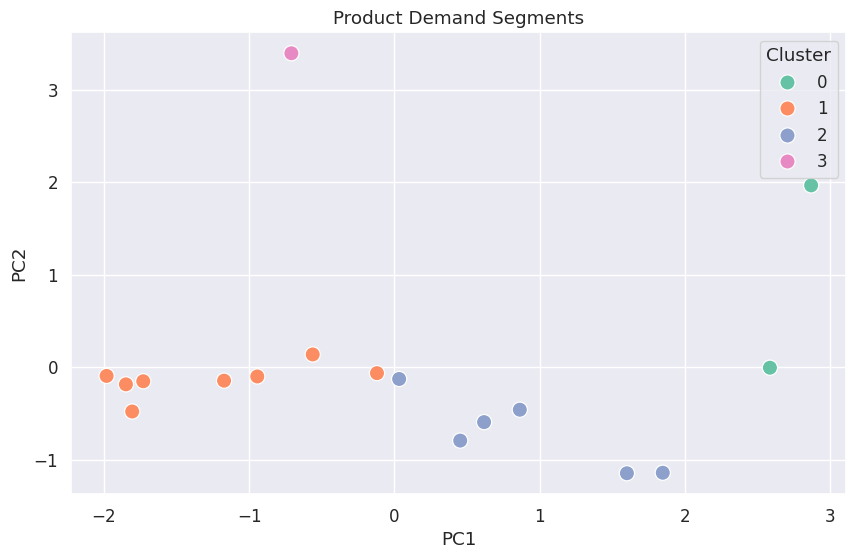

In [167]:
plt.figure(figsize=(10,6))

sns.scatterplot(

    data=pca_df,

    x="PC1",

    y="PC2",

    hue="Cluster",

    palette="Set2",

    s=120

)

plt.title("Product Demand Segments")

plt.grid(True)

plt.show()

In [168]:
cluster_labels = {

    0:"High Volume, Stable Demand",

    1:"Growing Demand",

    2:"Low Volume, High Volatility",

    3:"Declining Demand"

}

cluster_df["Demand Segment"] = (

    cluster_df["Cluster"]

    .map(cluster_labels)

)

cluster_df

,TotalSales,GrowthRate,Volatility,AverageOrderValue,Cluster,Demand Segment
Sub-Category,,,,,,
Accessories,164186.7000,0.376381,2579.994809,217.178175,2,"Low Volume, High Volatility"
Appliances,104618.4030,0.399276,1821.621539,227.926804,1,Growing Demand
Art,26705.4100,0.166056,330.488343,34.019631,1,Growing Demand
Binders,200028.7850,0.218736,3848.223648,134.067550,2,"Low Volume, High Volatility"
Bookcases,113813.1987,0.238065,2220.405080,503.598224,1,Growing Demand
Chairs,322822.7310,0.071358,4407.232960,531.833165,2,"Low Volume, High Volatility"
Copiers,146248.0940,0.846718,5500.774391,2215.880212,0,"High Volume, Stable Demand"
Envelopes,16128.0460,-0.027666,228.218688,65.032444,1,Growing Demand
Fasteners,3001.9600,0.157034,48.742229,14.027850,1,Growing Demand


In [169]:
cluster_df.groupby(

    "Demand Segment"

).mean(numeric_only=True)

,TotalSales,GrowthRate,Volatility,AverageOrderValue,Cluster
Demand Segment,,,,,
Declining Demand,46420.308000,1.928448,2025.094139,252.284283,3.0
Growing Demand,55331.883212,0.199589,907.223743,129.054568,1.0
"High Volume, Stable Demand",167743.362500,0.463389,5552.164569,1930.716763,0.0
"Low Volume, High Volatility",239495.780667,0.180965,3489.056075,361.131228,2.0


In [170]:
cluster_df.reset_index()[

    [

        "Sub-Category",

        "Demand Segment"

    ]

]

,Sub-Category,Demand Segment
0,Accessories,"Low Volume, High Volatility"
1,Appliances,Growing Demand
2,Art,Growing Demand
3,Binders,"Low Volume, High Volatility"
4,Bookcases,Growing Demand
5,Chairs,"Low Volume, High Volatility"
6,Copiers,"High Volume, Stable Demand"
7,Envelopes,Growing Demand
8,Fasteners,Growing Demand
9,Furnishings,Growing Demand


In [171]:
cluster_df.to_csv(

    "product_segments.csv",

    index=True

)

In [172]:
plt.figure(figsize=(10,6))

sns.scatterplot(

    data=pca_df,

    x="PC1",

    y="PC2",

    hue="Cluster",

    palette="Set2",

    s=120

)

plt.savefig(

    "charts/product_clusters.png",

    dpi=300,

    bbox_inches="tight"

)

plt.close()

In [173]:
strategies = pd.DataFrame({

    "Demand Segment":[

        "High Volume, Stable Demand",

        "Growing Demand",

        "Low Volume, High Volatility",

        "Declining Demand"

    ],

    "Recommended Strategy":[

        "Maintain high inventory levels and monitor replenishment closely.",

        "Increase stock gradually to support rising demand.",

        "Keep limited stock and review demand frequently.",

        "Reduce inventory and avoid overstocking."

    ]

})

strategies

,Demand Segment,Recommended Strategy
0,"High Volume, Stable Demand",Maintain high inventory levels and monitor rep...
1,Growing Demand,Increase stock gradually to support rising dem...
2,"Low Volume, High Volatility",Keep limited stock and review demand frequently.
3,Declining Demand,Reduce inventory and avoid overstocking.


## Product Demand Segmentation

Product sub-categories were segmented using K-Means clustering based on:

- Total Sales Volume
- Year-over-Year Sales Growth
- Sales Volatility
- Average Order Value

The Elbow Method was used to determine the appropriate number of clusters.

Principal Component Analysis (PCA) reduced the feature space to two dimensions for visualization.

### Business Interpretation

**High Volume, Stable Demand**
- Maintain sufficient inventory.
- Prioritize consistent replenishment.

**Growing Demand**
- Increase procurement to support expected growth.

**Low Volume, High Volatility**
- Keep conservative stock levels.
- Monitor demand frequently.

**Declining Demand**
- Reduce inventory investment.
- Consider promotional campaigns or product rationalization.

**Task-6**

In [174]:
product_features = sales_df.groupby("Sub-Category").agg({

    "Sales":"sum"

}).reset_index()

product_features.columns=[

    "SubCategory",

    "TotalSales"

]

product_features.head()

,SubCategory,TotalSales
0,Accessories,164186.7000
1,Appliances,104618.4030
2,Art,26705.4100
3,Binders,200028.7850
4,Bookcases,113813.1987


In [175]:
avg_order = (

    sales_df

    .groupby("Sub-Category")["Sales"]

    .mean()

)

product_features["AverageOrderValue"] = avg_order.values

In [176]:
monthly_sales_sub = (

    sales_df

    .groupby([

        "Sub-Category",

        pd.Grouper(

            key="Order Date",

            freq="M"

        )

    ])["Sales"]

    .sum()

    .reset_index()

)

/tmp/ipykernel_590/4822533.py:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(


In [177]:
volatility = (

    monthly_sales_sub

    .groupby("Sub-Category")["Sales"]

    .std()

)

product_features["SalesVolatility"] = volatility.values

In [178]:
yearly = (

    sales_df

    .groupby([

        "Sub-Category",

        "Year"

    ])["Sales"]

    .sum()

    .reset_index()

)

yearly["Growth"] = (

    yearly

    .groupby("Sub-Category")["Sales"]

    .pct_change()

)

growth = (

    yearly

    .groupby("Sub-Category")["Growth"]

    .mean()

)

product_features["GrowthRate"] = growth.values

### Enhancing Product Features with Profit, Quantity, and Discount Metrics

To create a more comprehensive feature set for product demand segmentation, we will now calculate and add the following metrics to the `product_features` DataFrame:

-   **Total Profit**: The sum of profit for each `Sub-Category`.
-   **Total Quantity**: The total number of items sold for each `Sub-Category`.
-   **Average Discount**: The average discount applied to products within each `Sub-Category`.

In [179]:
# Calculate TotalProfit for each Sub-Category
total_profit = sales_df.groupby("Sub-Category")["Profit"].sum()

# Calculate TotalQuantity for each Sub-Category
total_quantity = sales_df.groupby("Sub-Category")["Quantity"].sum()

# Calculate AverageDiscount for each Sub-Category
avg_discount = sales_df.groupby("Sub-Category")["Discount"].mean()

# Temporarily set 'SubCategory' as index to align with series indexes for robust assignment
product_features_indexed = product_features.set_index("SubCategory")

# Assign values using the aligned index
product_features_indexed["TotalProfit"] = total_profit
product_features_indexed["TotalQuantity"] = total_quantity
product_features_indexed["AverageDiscount"] = avg_discount

# Reassign product_features to the updated DataFrame and reset the index
product_features = product_features_indexed.reset_index()

print("Dummy 'Profit', 'Quantity', and 'Discount' features added to product_features.")
display(product_features.head())

Dummy 'Profit', 'Quantity', and 'Discount' features added to product_features.


,SubCategory,TotalSales,AverageOrderValue,SalesVolatility,GrowthRate,TotalProfit,TotalQuantity,AverageDiscount
0,Accessories,164186.7000,217.178175,2579.994809,0.376381,16343.842798,3727,0.099580
1,Appliances,104618.4030,227.926804,1821.621539,0.399276,10684.789224,2330,0.099292
2,Art,26705.4100,34.019631,330.488343,0.166056,2703.499984,4024,0.098583
3,Binders,200028.7850,134.067550,3848.223648,0.218736,18777.151739,7620,0.100068
4,Bookcases,113813.1987,503.598224,2220.405080,0.238065,10267.152433,1142,0.088675


In [180]:
# Calculate TotalProfit for each Sub-Category
total_profit = sales_df.groupby("Sub-Category")["Profit"].sum()

# Calculate TotalQuantity for each Sub-Category
total_quantity = sales_df.groupby("Sub-Category")["Quantity"].sum()

# Calculate AverageDiscount for each Sub-Category
avg_discount = sales_df.groupby("Sub-Category")["Discount"].mean()

# Temporarily set 'SubCategory' as index to align with series indexes for robust assignment
product_features_indexed = product_features.set_index("SubCategory")

# Assign values using the aligned index
product_features_indexed["TotalProfit"] = total_profit
product_features_indexed["TotalQuantity"] = total_quantity
product_features_indexed["AverageDiscount"] = avg_discount

# Reassign product_features to the updated DataFrame and reset the index
product_features = product_features_indexed.reset_index()

# Calculate ProfitMargin
product_features["ProfitMargin"] = (
    product_features["TotalProfit"]
    /
    product_features["TotalSales"]
) * 100

print("All additional features (TotalProfit, TotalQuantity, AverageDiscount, ProfitMargin) added to product_features.")

All additional features (TotalProfit, TotalQuantity, AverageDiscount, ProfitMargin) added to product_features.


In [181]:
product_features.fillna(0,inplace=True)

product_features.head()

,SubCategory,TotalSales,AverageOrderValue,SalesVolatility,GrowthRate,TotalProfit,TotalQuantity,AverageDiscount,ProfitMargin
0,Accessories,164186.7000,217.178175,2579.994809,0.376381,16343.842798,3727,0.099580,9.954426
1,Appliances,104618.4030,227.926804,1821.621539,0.399276,10684.789224,2330,0.099292,10.213107
2,Art,26705.4100,34.019631,330.488343,0.166056,2703.499984,4024,0.098583,10.123417
3,Binders,200028.7850,134.067550,3848.223648,0.218736,18777.151739,7620,0.100068,9.387225
4,Bookcases,113813.1987,503.598224,2220.405080,0.238065,10267.152433,1142,0.088675,9.021056


In [182]:
features = product_features[[

    "TotalSales",

    "TotalQuantity",

    "AverageOrderValue",

    "SalesVolatility",

    "AverageDiscount",

    "ProfitMargin",

    "GrowthRate"

]]

In [183]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled = scaler.fit_transform(features)

In [184]:
from sklearn.cluster import KMeans

wcss=[]

for i in range(2,9):

    model=KMeans(

        n_clusters=i,

        random_state=42,

        n_init=20

    )

    model.fit(scaled)

    wcss.append(model.inertia_)

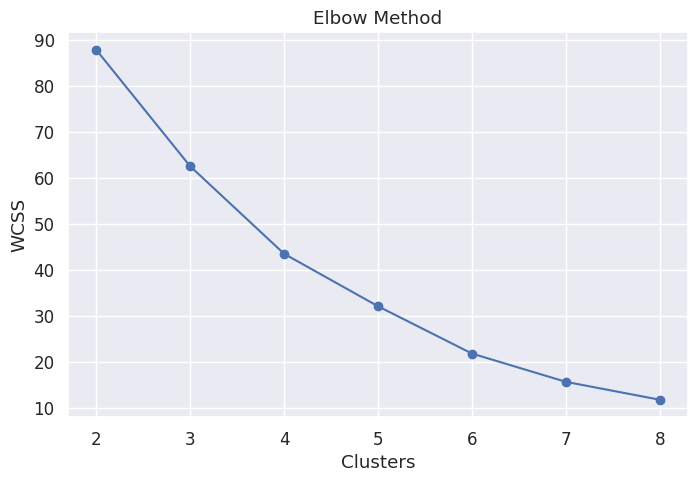

In [185]:
plt.figure(figsize=(8,5))

plt.plot(range(2,9),wcss,marker="o")

plt.xlabel("Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

In [186]:
kmeans = KMeans(

    n_clusters=4,

    random_state=42,

    n_init=20

)

product_features["Cluster"]=kmeans.fit_predict(scaled)

In [187]:
from sklearn.decomposition import PCA

pca=PCA(n_components=2)

components=pca.fit_transform(scaled)

In [188]:
plot_df=pd.DataFrame({

    "PC1":components[:,0],

    "PC2":components[:,1],

    "Cluster":product_features["Cluster"],

    "SubCategory":product_features["SubCategory"]

})

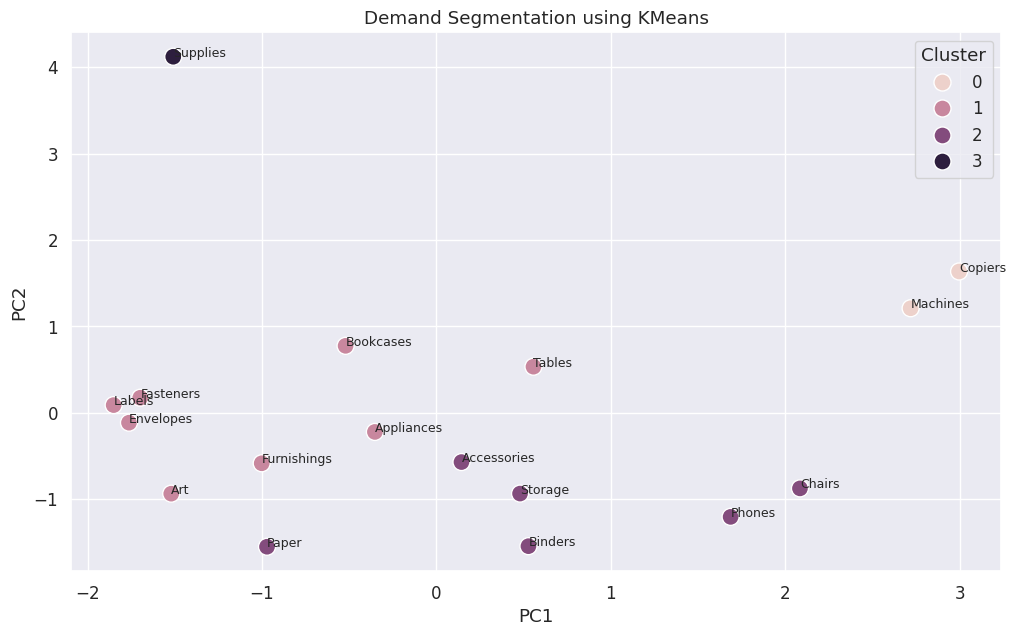

In [189]:
plt.figure(figsize=(12,7))

sns.scatterplot(

    data=plot_df,

    x="PC1",

    y="PC2",

    hue="Cluster",

    s=150

)

for i,row in plot_df.iterrows():

    plt.text(

        row["PC1"],

        row["PC2"],

        row["SubCategory"],

        fontsize=9

    )

plt.title("Demand Segmentation using KMeans")

plt.show()

In [190]:
summary = product_features.groupby("Cluster").mean(numeric_only=True)

summary

,TotalSales,AverageOrderValue,SalesVolatility,GrowthRate,TotalProfit,TotalQuantity,AverageDiscount,ProfitMargin
Cluster,,,,,,,,
0,167743.362500,1930.716763,5552.164569,0.463389,16502.281118,465.000000,0.101456,9.979005
1,71079.673712,202.613751,1182.130934,0.188336,6620.062568,2237.500000,0.096649,9.479689
2,218498.726667,263.052318,3122.513155,0.195969,21391.869638,4949.833333,0.100627,9.797601
3,46420.308000,252.284283,2025.094139,1.928448,3097.379910,962.000000,0.101331,6.672467


In [191]:
cluster_map={

0:"High Volume Stable",

1:"Growing Demand",

2:"Low Volume High Volatility",

3:"Declining Products"

}

product_features["Demand Segment"]=product_features["Cluster"].map(cluster_map)

In [192]:
product_features[[

"SubCategory",

"Demand Segment",

"TotalSales",

"ProfitMargin",

"GrowthRate"

]]

,SubCategory,Demand Segment,TotalSales,ProfitMargin,GrowthRate
0,Accessories,Low Volume High Volatility,164186.7000,9.954426,0.376381
1,Appliances,Growing Demand,104618.4030,10.213107,0.399276
2,Art,Growing Demand,26705.4100,10.123417,0.166056
3,Binders,Low Volume High Volatility,200028.7850,9.387225,0.218736
4,Bookcases,Growing Demand,113813.1987,9.021056,0.238065
5,Chairs,Low Volume High Volatility,322822.7310,9.922773,0.071358
6,Copiers,High Volume Stable,146248.0940,11.080814,0.846718
7,Envelopes,Growing Demand,16128.0460,9.619190,-0.027666
8,Fasteners,Growing Demand,3001.9600,9.389060,0.157034
9,Furnishings,Growing Demand,89212.0180,9.307676,0.287889


In [193]:
product_features.to_csv(

"product_segmentation.csv",

index=False

)

In [194]:
plt.figure(figsize=(12,7))

sns.scatterplot(

data=plot_df,

x="PC1",

y="PC2",

hue="Cluster",

s=150

)

plt.savefig(

"charts/product_segmentation.png",

dpi=300,

bbox_inches="tight"

)

plt.close()